# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— baseline_linear_regression_pipeline.pkl — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть baseline_linear_regression_pipeline.pkl и train_data.csv и test_data.csv.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите .pkl файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



# **Авторское решение**

# **Разработка нелинейной модели регрессии для почасового прогнозирования спроса на аренду велосипедов в условиях черноморского климата**

- Автор: Татьяна Дмитриева
- Дата: 04.06.2026

**Описание исследования**: В рамках данного проекта исследуется процесс предсказания почасового спроса на аренду велосипедов на основе погодных, календарных и сезонных условий для логистической системы компании `"BikeSouth"`. Работа охватывает полный цикл разработки ML-решения: от первичного и исследовательского анализа данных (`EDA`) до оптимизации нелинейных моделей и сохранения финального пайплайна. Приоритетными задачами в рамках проекта являются выявление сложных нелинейных взаимосвязей и эффектов взаимодействия признаков (таких как сочетание экстремальной температуры, влажности и осадков), с которыми не справлялась базовая линейная модель.  

**Цель исследования**: Построить модель машинного обучения, которая максимально точно прогнозирует количество арендованных велосипедов за конкретный час, превосходя по качеству базовую линейную регрессию и обеспечивая минимальное значение метрики `RMSE` как на кросс-валидации по обучающей выборке, так и на отложенных тестовых данных.  

**Задачи исследования**:  
- изучить структуру предоставленных датасетов (`ds_s14_train_data.csv`, `ds_s14_test_data.csv`), провести исследовательский анализ данных (`EDA`) и оценить показатели качества исходного baseline-пайплайна линейной регрессии по метрикам `RMSE`, `R²` и `MAE`;  
- провести конструирование признаков на основе исходных данных для выявления скрытых закономерностей, не представленных в датасете в явном виде;
- подготовить пайплайны предобработки данных, включая кодирование категориальных признаков и обязательное масштабирование числовых данных для корректной работы метрических алгоритмов без утечек из тестовой выборки;  
- разработать кастомный трансформер (используя принципы ООП) для конструирования новых погодных факторов и технической стандартизации признаков, интегрировав его в единый пайплайн библиотеки `sklearn`;  
- построить и обучить нелинейные модели регрессии (`kNN` и дерево решений) на единой схеме кросс-валидации с 5 фолдами;
- подобрать оптимальные гиперпараметры моделей с использованием библиотеки `Optuna` и алгоритмов байесовской оптимизации;  
- свести результаты лучших нелинейных моделей в итоговую таблицу метрик (`RMSE`, `R²`, `MAE`), выбрать наилучший подход и выполнить его однократную финальную проверку на тестовой выборке;  
- проанализировать важность признаков для интерпретируемой модели решающего дерева с целью извлечения бизнес-инсайтов, сформировать аналитические выводы для бизнеса и сохранить финальный пайплайн в формате `.joblib` для промышленной эксплуатации. 

_____
**Исходные данные**:  

Для проведения исследовния были предоставлены:
- базовая модель в виде готового обученного пайплайна (без исходного кода) (`baseline_linear_regression_pipeline.joblib`);  
- датасет для обучения и валидации модели (`ds_s14_train_data.csv`);  
- датасет для финальной проверки модели и итоговой оценки её качества (`ds_s14_test_data.csv`).  

Датасеты содержат почасовые данные об аренде велосипедов и погодные характеристики, влияющие на спрос:   

- `Temperature` — температура воздуха (`°C`);
- `Humidity` — относительная влажность воздуха, процент водяного пара в воздухе;
- `Windspeed` — скорость ветра, м/с;
- `Visibility` — видимость (в десятках метров);
- `Dew Point Temperature` — точка росы (`°C`);
- `Solar Radiation` — солнечная радиация (`МДж/м²` или `MJ/m²`);
- `Rainfall` — количество осадков (мм);
- `Snowfall` — количество снега (см);
- `Seasons` — времена года: `Winter` (зима), `Spring` (весна), `Summer` (лето), `Autumn` (осень);
- `Holiday` — выходной/праздничный или будний день: `Holiday` (выходной или праздник), `No Holiday` (будний день);
- `Functioning Day` — были ли велосипеды арендованы в рабочее время: `Yes` (да, функциональные часы), `No` (нет, техническое обслуживание станций проката);  
- Несколько колонок `Time_Period` (со значениями `True` и `False`), где каждая запись в датасете относится к одному из пяти временных периодов:

• `Night` — c 00:00 по 05:59;  
• `Morning` — с 06:00 по 09:59;  
• `Daytime` — с 10:00 по 15:59;   
• `Evening` — с 16:00 по 19:59;  
• `Late Evening` — с 20:00 по 23:59.  

Данные о периоде `Daytime` — это базовое состояние. Запись, у которой в четырёх колонках c временными промежутками указано значение `False`, автоматически относится к периоду `Daytime`.

- `Rented Bike Count` — это целевая переменная. Она содержит количество велосипедов, арендованных за конкретный час. Значение отражает почасовой спрос на аренду, и именно от точности прогноза этой величины зависит стабильность работы всей логистической системы компании.

_______

**Поставновка задачи машинного обучения**

***Тип задачи***   
Проект реализуется в рамках задачи одномерной регрессии с учителем (`Supervised Learning` / `Regression`). На основе комплекса погодных, временных и календарных метрик модель должна предсказывать непрерывную числовую величину - часовой спрос на аренду транспортных средств.

***Целевой признак (`Target`)***:   
`Rented Bike Count` - непрерывная числовая величина, отражающая количество арендованных велосипедов за конкретный часовой интервал.

***Проблема***   
Логистическая служба компании `"BikeSouth"` сталкивается с серьезными издержками из-за низкой точности базовой модели линейной регрессии, которая не способна улавливать нелинейные погодные эффекты и аномалии черноморского климата. Это несет в себе двойную угрозу:  
- Экономическую: неточный прогноз приводит к дефициту велосипедов в пиковые часы (упущенная прибыль), либо к избыточному простою неиспользуемого транспорта (излишние операционные затраты на логистику и обслуживание);  
- Репутационную: отсутствие свободных велосипедов в моменты высокого спроса снижает лояльность жителей и туристов города, вынуждая их переходить к конкурентам.  

***Цель бизнеса***   
Обеспечить логистическую систему `"BikeSouth"` надежным аналитическим инструментом для точного планирования общего объема доступного транспорта на линии. Это позволит:
- своевременно выводить необходимое количество велосипедов на улицы города в периоды пикового спроса и вовремя проводить техническое обслуживание в периоды затишья;
- минимизировать операционные издержки на холостой простой и избыточную готовность сервиса;
- максимизировать выручку за счет полного удовлетворения общего спроса жителей и туристов в конкретные часы.

***Логика ML***   
Алгоритм анализирует совокупность признаков окружающей среды (температура, влажность, скорость ветра, видимость, солнечная радиация, осадки), а также временной контекст (час суток, день недели, сезон, праздничные дни). На основе этих данных нелинейные модели (`kNN` и дерево решений) находят сложные паттерны совокупного поведения пользователей в аналогичных погодных условиях. Результатом работы сквозного автоматизированного пайплайна является точечное предсказание суммарного количества аренд по всей сети за час, минимизирующее отклонение от реальных значений.

***Обоснование выбора метрик***   
Для оценки качества моделей регрессии используется одна ключевая и две вспомогательные метрики:
- `RMSE` (`Root Mean Squared Error`) - основная метрика. Она наиболее критично оценивает крупные ошибки модели (за счет возведения отклонений в квадрат), что крайне важно для бизнеса: сильный недопрогноз или перепрогноз объема велосипедов наносит компании наибольший финансовый ущерб;  
- `MAE` (`Mean Absolute Error`) - вспомогательная метрика. Позволяет оценить среднюю абсолютную величину ошибки модели в реальных единицах (штуках велосипедов) без сильного влияния единичных выбросов;  
- `R²` (`Коэффициент детерминации`) - вспомогательная метрика. Показывает долю дисперсии целевого признака, объясненную моделью, и позволяет оценить, насколько разработанные нелинейные модели работают лучше, чем простое предсказание по среднему значению.

***Ожидаемый результат***   
Обученный и оптимизированный с помощью библиотеки `Optuna` пайплайн машинного обучения, который выдает надежный прогноз часового спроса. Модель должна продемонстрировать на кросс-валидации и отложенной тестовой выборке метрики качества, превосходящие базовую линейную регрессию, снижая показатель `RMSE`. Это позволит автоматизировать логистику `BikeSouth` и снизить операционные риски.
  
_____
# Структура проекта

[1. Подготовка среды и загрузка данных](#1-bullet)  
[2. Оценка качества базовой модели (`Baseline`)](#2-bullet)  
[3. Исследовательский анализ данных (`EDA`)](#3-bullet)  
[4. Разделение выборки и предобработка данных](#4-bullet)  
[5. Создание признаков и реализация кастомного трансформера](#5-bullet)  
[6. Обучение новых нелинейных моделей (`KNN` и `Decision Tree`)](#6-bullet)  
[7. Подбор гиперпараметров моделей с помощью `Optuna`](#7-bullet)  
[8. Кросс-валидация новых моделей](#8-bullet)  
[9. Составление отчета по моделям](#9-bullet)  
[10. Финальное тестирование и оценка качества модели](#10-bullet)  
[11. Подготовка артефактов и сохранение финальной модели](#11-bullet)  
[12. Аналитические выводы о результатах работы](#12-bullet)  
______

<a id="1-bullet"></a>
## Подготовка среды и загрузка данных

Для начала подготовим рабочее окружение: установим и импортируем необходимые библиотеки для обработки данных, визуализации и машинного обучения. Группировку импортов выполняем согласно стандарту `PEP 8` (стандартные библиотеки, сторонние, затем инструменты `ML`). Для корректной работы проекта и воспроизводимости результатов версии используемых библиотек зафиксированы в файле `requirements.txt`. Ссылка на файл дана в конце проекта.

In [1]:
# Импорт системного модуля для очистки экрана (из стандартной библиотеки)
from IPython.display import clear_output

# Установка сторонних библиотек для анализа нелинейных зависимостей и оптимизации параметров
!pip install phik optuna -q
!pip install --upgrade --force-reinstall --no-cache-dir numpy==1.26.4 scikit-learn==1.6.1 -q

# Финальная очистка вывода ячейки от системных логов и предупреждений pip
clear_output()

# Импорты из стандартной библиотеки
import logging
import os
import urllib.request
import warnings

# Импорты сторонних библиотек
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from phik import phik_matrix

# Инструменты машинного обучения (Scikit-Learn)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

# Настройка отображения графиков и предупреждений
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# Полное принудительное отключение корневого логгера Optuna для скрытия розовых уведомлений
logging.getLogger("optuna").setLevel(logging.WARNING)

# Фиксация константы Random State для воспроизводимости результатов
RANDOM_STATE = 42

Библиотеки `pandas` и `numpy` будут применяться для загрузки и трансформации табличных данных. Модули `matplotlib` и `seaborn` использоваться для построения графиков на этапе исследовательского анализа (`EDA`). Инструмент `phik_matrix` необходим для выявления нелинейных взаимосвязей между признаками различных типов (категориальными и непрерывными) на этапе `EDA`. Классы `StandardScaler` и `OneHotEncoder` в связке с `ColumnTransformer` позволят создать автоматизированный процесс масштабирования числовых переменных и кодирования категорий. Это исключит риск утечки данных (`data leakage`) при кросс-валидации. 

Регрессоры `KNeighborsRegressor` и `DecisionTreeRegressor` загружаем для решения основной задачи. Функции `cross_val_score` и `KFold` будут использоваться для реализации кросс-валидации. Метрики `root_mean_squared_error`, `mean_absolute_error` и `r2_score` импортируются для оценки качества прогнозов.

Загрузим предоставленные для исследования данные и проведем первичную проверку структуры файлов, чтобы убедиться в их целостности и корректности для дальнейшего исследования. Для загрузки данных подготовим словарь, сопоставляющий названия таблиц с именами их файлов. Загрузка реализована через конструкцию `try-except`: система сначала попытается найти файлы по пути `/datasets/` (при проверке проекта на учебной платформе), а в случае их отсутствия - загрузит данные из удаленного хранилища (`S3`) по ссылкам. Такой подход обеспечит универсальность кода и позволит беспрепятственно запускать проект как в локальном окружении, так и на сервере.

In [2]:
# Словарь соответствия имен датафреймов и файлов
data_files = {
    'df_train': 'ds_s14_train_data.csv',
    'df_test': 'ds_s14_test_data.csv'
}

# Словарь для хранения загруженных датафреймов
datasets = {}

# Обеспечиваем два варианта запуска проекта (как в локальном окружении, так и на сервере)
for table_name, file_name in data_files.items():
    path_platform = f'/datasets/{file_name}'
    path_local = file_name
    
    try:
        # Попытка загрузки из папки учебной платформы
        datasets[table_name] = pd.read_csv(path_platform)
        display(f"Таблица {table_name} успешно загружена из папки /datasets/")
    except Exception:
        try:
            # Попытка загрузки из локального окружения
            datasets[table_name] = pd.read_csv(path_local)
            display(f"Таблица {table_name} успешно загружена из локального окружения")
        except Exception as e:
            display(f"Ошибка при загрузке таблицы {table_name}: {e}")

# Извлечение датафреймов из словаря в переменные
df_train = datasets.get('df_train')
df_test = datasets.get('df_test')

'Таблица df_train успешно загружена из папки /datasets/'

'Таблица df_test успешно загружена из папки /datasets/'

После загрузки необходимо убедиться в корректности структуры данных. Проверим первые строки и общую информацию по обеим таблицам, чтобы оценить объемы и типы данных, а также выявить наличие явных пропусков.

In [3]:
# Выводим первые строки и информацию о датафрейме для обучаеющей выборки
display("Первые строки обучающей выборки:")
display(df_train.head().T)
display(df_train.info())

'Первые строки обучающей выборки:'

,0,1,2,3,4
Temperature,20.3,25.4,-6.9,-5.2,23.4
Humidity(%),35.0,55.0,39.0,37.0,34.0
Wind speed (m/s),2.4,3.2,1.6,2.2,2.1
Visibility (10m),2000.0,2000.0,2000.0,2000.0,2000.0
Dew point temperature,4.3,15.6,-18.5,-17.6,6.6
Solar Radiation (MJ/m2),0.46,0.15,0.0,0.0,2.84
Rainfall(mm),0.0,0.0,0.0,0.0,0.0
Snowfall (cm),0.0,0.0,0.0,0.0,0.0
Seasons,Autumn,Autumn,Winter,Winter,Autumn
Holiday,Holiday,No Holiday,No Holiday,No Holiday,No Holiday


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

None

In [4]:
# Выводим первые строки и информацию о датафрейме для тестовой выборки
display("Первые строки тестовой выборки:")
display(df_test.head().T)
display(df_test.info())

'Первые строки тестовой выборки:'

,0,1,2,3,4
Temperature,6.7,-5.3,2.9,23.1,23.3
Humidity(%),48.0,90.0,66.0,63.0,43.0
Wind speed (m/s),0.8,1.1,1.2,2.6,1.2
Visibility (10m),817.0,311.0,173.0,949.0,1257.0
Dew point temperature,-3.5,-6.6,-2.8,15.6,10.0
Solar Radiation (MJ/m2),0.39,0.0,0.0,1.68,1.91
Rainfall(mm),0.0,0.0,0.0,0.0,0.0
Snowfall (cm),0.0,2.2,0.0,0.0,0.0
Seasons,Winter,Winter,Winter,Spring,Summer
Holiday,No Holiday,No Holiday,No Holiday,No Holiday,No Holiday


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Per

None

Как можно заметить, обе таблицы успешно загружены. Механизм автоматического переключения путей (`try-except`) отработал корректно, обеспечив отказоустойчивый доступ к содержащимся в них данным. По результатам первичного анализа датасетов можно сделать следующие выводы:

- Основная обучающая таблица `df_train` содержит 7008 записей, а отложенная тестовая таблица `df_test` - 1752 записи. Их соотношение составляет 80:20, что является классическим стандартом для валидации в задачах машинного обучения.
- Названия столбцов и их содержание в обеих таблицах полностью идентичны и соответствуют описанию проекта.
- Целевой признак `Rented Bike Count` представлен в целочисленном формате, пропусков не имеет. 
- Классы целевой переменной непрерывны, что подтверждает корректность постановки задачи регрессии.
- В обеих выборках обнаружены скрытые пропуски в 6 метеорологических признаках (`влажность`, `скорость ветра`, `видимость`, `солнечная радиация`, `количество осадков` и `количество снега`). Это потребует обязательной разработки стратегии импутации.
- Признаки временных периодов (`Time_Period_...`) уже бинаризованы (`bool`), однако ключевые категориальные переменные (`Seasons`, `Holiday`, `Functioning Day`) распознаны как `object` и требуют кодирования перед подачей в нелинейные модели.

Среда выполнения полностью подготовлена к работе. Все необходимые программные модули импортированы, зафиксирован единый параметр `RANDOM_STATE = 42` для обеспечения идентичности результатов при повторных запусках расчетов. Дальнейшая работа на этапе `EDA` будет сосредоточена на изучении распределения спроса на велосипеды и поиске скрытых нелинейных взаимосвязей. Основной акцент в исследовательском анализе будет сделан на оценке физического взаимодействия погодных факторов (`температуры` и `влажности`) и анализе влияния признака `Functioning Day` на нулевой спрос. Это позволит сформулировать точные гипотезы для создания кастомного трансформера признаков и избежать переобучения будущих моделей `kNN` и `решающего дерева`.

<a id="2-bullet"></a>
## Оценка качества базовой модели (`Baseline`)

Оценим качество работы базовой модели линейной регрессии, предоставленной компанией `BikeSouth`. Модель поставляется в виде готового обученного пайплайна `baseline_linear_regression_pipeline.pkl`. Поскольку пайплайн содержит в себе все необходимые трансформации, предобработка данных вручную перед вызовом прогноза не требуется.

Для начала выгрузим файл `baseline_linear_regression_pipeline.pkl` и организуем разделение исходных датафреймов на матрицы объясняющих признаков и векторы целевой переменной `Rented Bike Count`.

In [5]:
# Загружаем пайплайн
baseline_pipeline = joblib.load(
    urllib.request.urlopen(
        "https://code.s3.yandex.net/data-scientist/baseline_linear_regression_pipeline.pkl"
    )
)
display("Пайплайн базовой модели успешно загружен.")

# Выделяем признаки и целевую переменную в обучающей выборке
X_train = df_train.drop(columns=['Rented Bike Count'])
y_train = df_train['Rented Bike Count']

# Выделяем признаки и целевую переменную в тестовой выборке
X_test = df_test.drop(columns=['Rented Bike Count'])
y_test = df_test['Rented Bike Count']

# Выводим размерности полученных матриц
display(f"Размерность X_train: {X_train.shape}, y_train: {y_train.shape}")
display(f"Размерность X_test: {X_test.shape}, y_test: {y_test.shape}")

'Пайплайн базовой модели успешно загружен.'

'Размерность X_train: (7008, 15), y_train: (7008,)'

'Размерность X_test: (1752, 15), y_test: (1752,)'

Файл базовой модели `baseline_linear_regression_pipeline.pkl` успешно импортирован в рабочее пространство. Полученные контрольные размерности матриц `X_train`: (7008, 15) и `X_test`: (1752, 15) полностью соответствуют методологии проекта: количество строк в матрицах факторов в точности совпадает с объемами исходных тренировочной и отложенной выборок, а количество столбцов уменьшилось с 16 до 15, что подтверждает корректное исключение целевого признака `Rented Bike Count` из объясняющих факторов. Идентичность структуры признаков в обеих выборках гарантирует корректность последующего вычисления прогнозов.

Передадим выделенные матрицы признаков `X_train` и `X_test` в загруженный пайплайн, сгенерируем векторы предсказаний спроса для обеих выборок и рассчитаем комплекс метрик `Baseline-модели` (`RMSE`, `MAE`, `R²`) с выводом результатов в сводную таблицу.

In [6]:
# Получаем прогнозы базовой модели для обеих выборок
y_pred_train = baseline_pipeline.predict(X_train)
y_pred_test = baseline_pipeline.predict(X_test)

# Рассчитываем метрики качества для обучающей выборки
rmse_train = root_mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Рассчитываем метрики качества для тестовой выборки
rmse_test = root_mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Выводидм сводную таблицу с результатами Baseline
baseline_results = pd.DataFrame({
    'Метрика': ['RMSE', 'MAE', 'R2'],
    'Train (Обучающая)': [rmse_train, mae_train, r2_train],
    'Test (Тестовая)': [rmse_test, mae_test, r2_test]
})

display("Качество работы базовой модели (Baseline):")
display(baseline_results.round(2))

'Качество работы базовой модели (Baseline):'

,Метрика,Train (Обучающая),Test (Тестовая)
0,RMSE,412.53,411.56
1,MAE,309.08,312.60
2,R2,0.59,0.59


Как можно заметить, загруженный пайплайн линейной регрессии успешно обработал поданные на вход сырые признаки, включая скрытые пропуски и категориальные значения, выдав непрерывные векторы предсказаний без генерации технических ошибок. Исполненный код не вызывает утечки данных (`Data Leakage`), так как к тестовой выборке применяется исключительно метод `predict()`, использующий ранее зафиксированные веса. 

Сформированная сводная таблица позволила получить точные численные показатели качества текущей модели:
- `RMSE` составляет 412,53 на обучающей выборке и 411,56 на отложенном тестовом наборе. Значение 411,56 официально фиксируется в качестве главного ориентира (`Baseline`) проекта. Будущие нелинейные алгоритмы будут считаться успешными только в том случае, если смогут показать ошибку ниже этого порога.
- `MAE` зафиксирована на отметке 309,08 для тренировочных данных и 312,60 для тестовых. Это свидетельствует о том, что в среднем линейная регрессия ошибается примерно на 310-313 арендованных велосипедов в конкретный час.
- `R²` равен 0,59 для обеих выборок. Это означает, что текущая модель способна объяснить лишь 59% дисперсии целевого признака, оставляя существенный потенциал для оптимизации.

Важной методологической особенностью полученных результатов является то, что метрики на обучающей и отложенной выборках практически идентичны. Это указывает на высокую стабильность линейной регрессии и полное отсутствие переобучения. Тем не менее, предсказательная способность модели уперлась в свой предел, поскольку линейный алгоритм по своей природе не способен улавливать нелинейные связи погодных факторов. Стоит учесть, что успешная работа базового пайплайна с сырыми данными обеспечена его внутренними встроенными механизмами. Для построения новых нелинейных моделей (в особенности `kNN`, критичного к пропускам и масштабу масштабирования) потребуется разработать собственную независимую систему предобработки, кодирования и импутации.

В рамках следующего исследовательского анализа данных (`EDA`) изучим распределение целевой переменной `Rented Bike Count`, визуализации погодных факторов и поиске скрытых нелинейных взаимосвязей. Особый акцент будет сделан на анализе работы сервиса в нерабочие дни (`Functioning Day`) и оценке мультиколлинеарности, что заложит основу для генерации новых признаков и проектирования собственного кастомного трансформера.

<a id="3-bullet"></a>
## Исследовательский анализ данных (`EDA`)

В данном разделе проведем комплексный исследовательский анализ данных (`Exploratory Data Analysis`) обучающей выборки. Цель этапа - детально изучить структуру распределений, выявить скрытые паттерны, аномалии и нелинейные зависимости, оценить объемы пропусков и дубликатов, а также проверить признаки на мультиколлинеарность. Полученные инсайты станут статистическим обоснованием для стратегии предобработки и генерации новых признаков в будущих пайплайнах.

### Анализ структуры данных и описательных статистик

Рассчитаем ключевые метрики распределения (среднее, медиана, квантили, экстремумы) для непрерывных факторов и оценка уникальности категориальных столбцов. Это необходимо для обнаружения физических аномалий, сильной скошенности данных или скрытых маркерных значений.

In [7]:
# Настраиваем формат отображения чисел с плавающей точкой
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Выводим описательные статистики для числовых признаков обучающей выборки
display("Описательные статистики числовых признаков:")
display(df_train.describe())

# Выводим описательные статистики для категориальных признаков
display("Описательные статистики категориальных признаков:")
display(df_train.describe(include=['object', 'bool']))

'Описательные статистики числовых признаков:'

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.00,6758.00,6798.00,6749.00,7008.00,6798.00,6746.00,6745.00,7008.00
mean,12.81,58.20,1.73,1435.16,4.02,0.57,0.15,0.07,705.61
std,11.92,20.34,1.04,607.29,13.03,0.87,1.16,0.44,646.31
min,-17.50,0.00,0.00,27.00,-30.60,0.00,0.00,0.00,0.00
25%,3.30,42.00,0.90,936.00,-4.70,0.00,0.00,0.00,190.75
50%,13.50,57.00,1.50,1691.00,5.00,0.01,0.00,0.00,504.50
75%,22.40,74.00,2.30,2000.00,14.80,0.94,0.00,0.00,1070.00
max,39.40,98.00,7.40,2000.00,26.80,3.52,35.00,8.80,3556.00


'Описательные статистики категориальных признаков:'

,Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night
count,7008,7008,7008,7008,7008,7008,7008
unique,4,2,2,2,2,2,2
top,Autumn,No Holiday,Yes,False,False,False,False
freq,1770,6668,6766,5840,5835,5836,5255


Метод `describe()` успешно рассчитан для всех типов признаков в обучающей выборке. По результатам анализа таблиц зафиксированы следующие фактические особенности:

- Исходя из статистик по целевому признаку (`Rented Bike Count`) среднее часовое значение спроса составляет 705,61 велосипедов, при этом медиана (50%) находится на уровне 504,50. Заметное превышение среднего над медианным значением, а также максимальный пик в 3556 арендованных велосипедов в час явно указывают на сильную правостороннюю скошенность (асимметрию) распределения целевой переменной. Минимальное значение равно 0, что требует сопоставления с периодами закрытия проката.
- Температурный диапазон от -17,50 °C до 39,40 °C (среднее значение 12,81 °C) выглядит физически корректным. 
- В распределении осадков (для `Rainfall(mm)` и `Snowfall (cm)`) даже 75-й квантиль равен 0,00, при этом максимумы доходят до 35,00 мм и 8,80 см соответственно. Это подтверждает, что подавляющее большинство наблюдений зафиксировано в сухую погоду, а распределение осадков имеет огромный пик в нуле и редкие экстремальные выбросы.
- Признак `Functioning Day` (функционирование сервиса) имеет 2 уникальных состояния. Самым частым является значение `Yes` (6766 часов из 7008), что означает, что в течение 242 часов прокат был закрыт по техническим или иным причинам. 
- Признак выходного дня `Holiday` принимает значение `No Holiday` в 6668 случаях. 
- Временные бинарные маркеры (`Time_Period_...`) сбалансированы: значение `False` преобладает в районе 5200-5800 строк для каждого периода, что математически верно отражает деление суток на 4 интервала.

### Технический аудит наименований признаков, типов данных и поиск дубликатов

В данном блоке выполним диагностический аудит табличной структуры обучающей выборки без изменения исходных данных. Проведем анализ наименований колонок на предмет скрытых пробелов и спецсимволов, оценим текущее состояние типов данных для категориальных факторов, а также выполним проверку на наличие полных дубликатов строк. Цель блока - сформировать техническое задание для будущего пайплайна предобработки.

In [8]:
# Анализируем наименования колонок на соответствие стилю snake_case
display("Диагностика названий колонок:")
problematic_cols = [col for col in df_train.columns if ' ' in col or '(' in col or col.isupper()]
display(f"Признаки, требующие технической очистки стиля: {problematic_cols}")

# Проверяем типы данных категориальных признаков
display("Проверка типов данных для качественных переменных:")
display(df_train[['Seasons', 'Holiday', 'Functioning Day']].dtypes)

# Осуществляем поиск полных дубликатов строк
duplicates_count = df_train.duplicated().sum()
display(f"Количество полных дубликатов в обучающей выборке: {duplicates_count}")

'Диагностика названий колонок:'

"Признаки, требующие технической очистки стиля: ['Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Functioning Day', 'Time_Period_Late Evening', 'Rented Bike Count']"

'Проверка типов данных для качественных переменных:'

Seasons            object
Holiday            object
Functioning Day    object
dtype: object

'Количество полных дубликатов в обучающей выборке: 0'

Аудит структуры данных успешно завершен, физические изменения в исходные таблицы на данном этапе не вносились:

- Выявлен массивный список колонок, наименования признаков в которых требуют технической очистки стиля: `Humidity(%)`, `Wind speed (m/s)`, `Visibility (10m)`, `Dew point temperature`, `Solar Radiation (MJ/m2)`, `Rainfall(mm)`, `Snowfall (cm)`, `Functioning Day`, `Time_Period_Late Evening`, а также целевая переменная `Rented Bike Count`. Наличие пробелов, скобок, косых черт и знаков процентов нарушает стандарт `snake_case`. Это подтверждает необходимость автоматизировать переименование колонок на этапе препроцессинга, чтобы избежать синтаксических ошибок при обращении к признакам.
- Качественные переменные `Seasons`, `Holiday` и `Functioning Day` имеют базовый тип `object`. Оставлять их в таком виде для нелинейных моделей нельзя. Зафиксирована необходимость их последующего кодирования через `OneHotEncoder` в составе единого `ColumnTransformer`.
- Проверка на наличие дубликатов показала 0 полных дубликатов строк в обучающей выборке. Временная структура данных не нарушена, избыточные повторы отсутствуют, ручная фильтрация строк на данном этапе не требуется.

### Анализ пропусков

В данном блоке проведем количественный и относительный аудит пропущенных значений в обучающей выборке. Понимание структуры пропусков необходимо для выбора математически корректного метода их заполнения (импутации). Поскольку на этапе первичного просмотра данных пропуски обнаружены в метеорологических факторах, прямое удаление строк недопустимо из-за риска потери ценной временной информации. Стратегия заполнения будет спроектирована таким образом, чтобы рассчитывать замещающие показатели (например, медианы) строго по обучающей выборке, исключая утечку данных в тест.

In [9]:
# Рассчитываем абсолютное количество пропусков по каждому признаку
missing_absolute = df_train.isna().sum()

# Рассчитываем относительное количество пропусков в процентах
missing_percentage = (df_train.isna().sum() / len(df_train)) * 100

# Формируем сводную таблицу по пропущенным значениям (выводим только те, где пропуски есть)
missing_table = pd.DataFrame({
    'Абсолютное количество': missing_absolute,
    'Доля пропусков (%)': missing_percentage
})

display("Анализ пропущенных значений в обучающей выборке:")
display(missing_table[missing_table['Абсолютное количество'] > 0].sort_values(by='Абсолютное количество', ascending=False))

'Анализ пропущенных значений в обучающей выборке:'

,Абсолютное количество,Доля пропусков (%)
Snowfall (cm),263,3.75
Rainfall(mm),262,3.74
Visibility (10m),259,3.70
Humidity(%),250,3.57
Wind speed (m/s),210,3.00
Solar Radiation (MJ/m2),210,3.00


На основе полученных результатов можно сделать следующие выводы:
- Пропуски присутствуют исключительно в метеорологических (физических) факторах и распределены по ним практически равномерно - в узком диапазоне от 3,00% до 3,75% для каждого признака. 
- Категориальные, бинарные и целевые признаки пропусков не имеют вовсе.
- Удаление строк с пропусками через `dropna()` недопустимо. Так как пропуски разнесены по разным метеорологическим признакам, их механическое удаление может привести к потере до 10-15% всей обучающей выборки, что нарушит непрерывность временного ряда и исказит реальную картину спроса на велосипеды.
- Хотя суммарный объем пропусков в каждом столбце невелик, алгоритм `KNeighborsRegressor` (`kNN`) технически не способен обучаться или предсказывать на матрицах со значениями `NaN`. Для некоторых современных реализаций алгоритмов на основе решающих деревьев заполнение пропусков не является обязательным, так как они умеют обрабатывать их на этапе деления узлов. Однако в рамках данного проекта используем классические модели из библиотеки `scikit-learn`, поэтому шаг импутации будет обязательным элементом будущего пайплайна как для `KNN`, так и для `Decision Tree`.

### Визуализация распределений признаков

В данном блоке выполним комплексное графическое исследование структуры обучающих данных. Для непрерывных метеорологических факторов построим гистограммы распределения плотности и "ящики с усами", позволяющие визуально оценить асимметрию, наличие тяжелых хвостов и скрытых пиков. Для дискретных и качественных переменных применим столбчатые диаграммы подсчета количества классов (`countplot`). Визуальный анализ формы распределений необходим для математического обоснования выбора заполняющих констант (медианы или среднего) и определения потребности в масштабировании факторов.

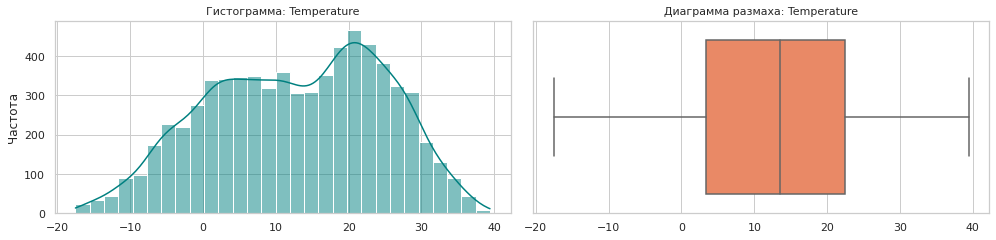

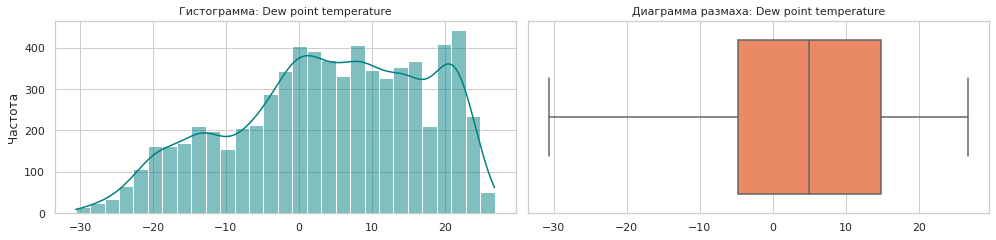

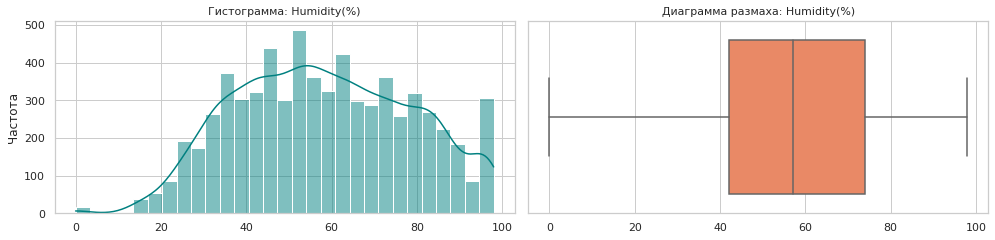

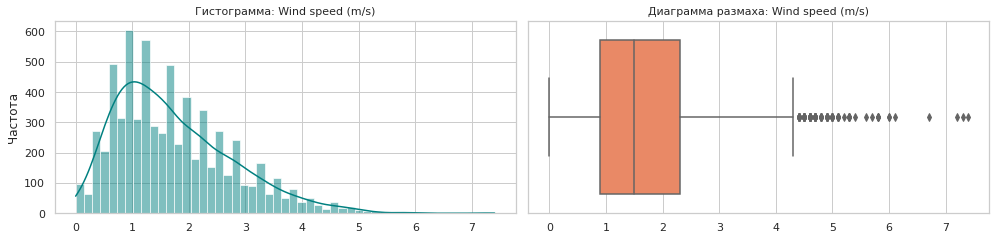

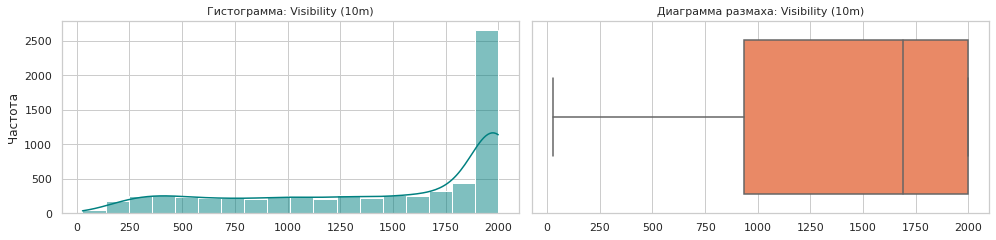

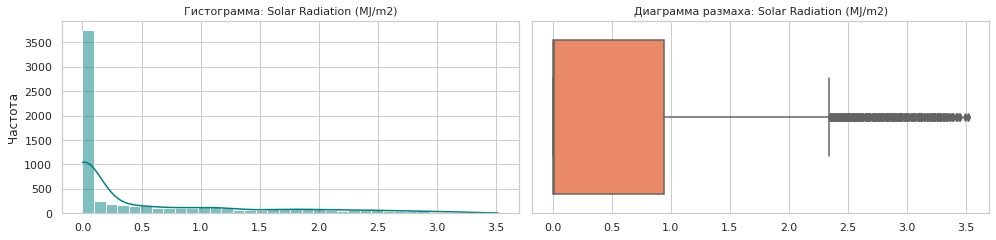

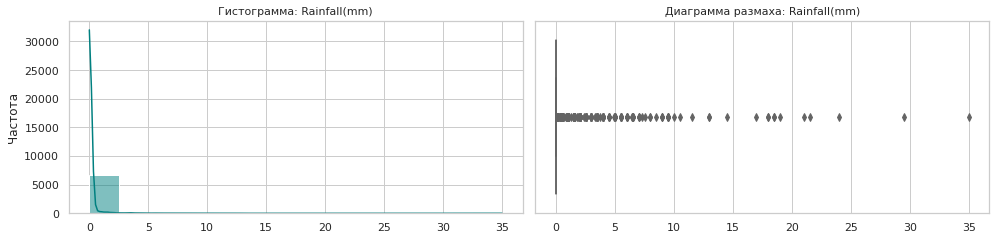

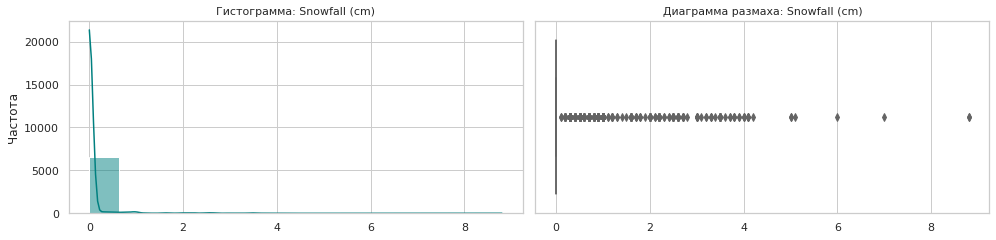

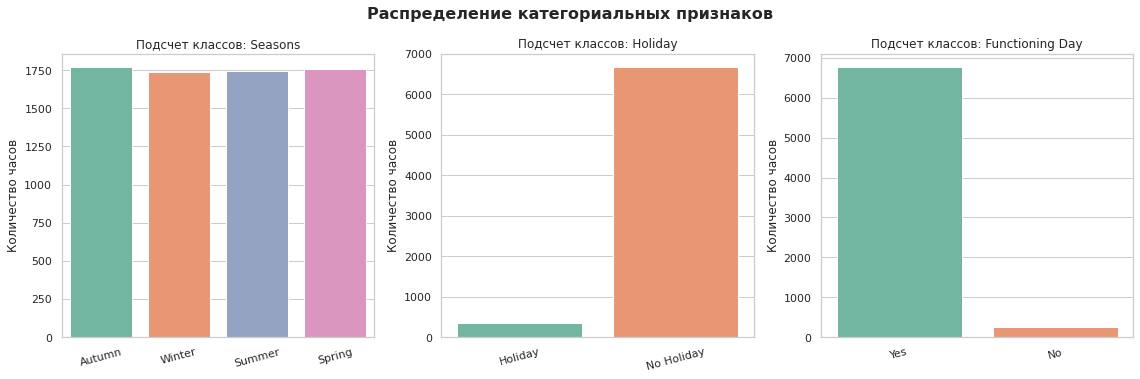

In [10]:
# Попарно построим графики (Гистограмма + Boxplot) для числовых признаков
numeric_cols = [
    'Temperature', 'Dew point temperature', 'Humidity(%)', 
    'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 
    'Rainfall(mm)', 'Snowfall (cm)'
]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
    
    # Левый график: гистограмма с кривой плотности (KDE)
    sns.histplot(data=df_train, x=col, kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f'Гистограмма: {col}', fontsize=11)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Частота')
    
    # Правый график: диаграмма Boxplot
    sns.boxplot(data=df_train, x=col, ax=axes[1], color='coral')
    axes[1].set_title(f'Диаграмма размаха: {col}', fontsize=11)
    axes[1].set_xlabel('')
    
    plt.tight_layout()
    plt.show()

# Построим графики распределения для категориальных признаков
discrete_cols = ['Seasons', 'Holiday', 'Functioning Day']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(discrete_cols):
    sns.countplot(data=df_train, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Подсчет классов: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество часов')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.suptitle('Распределение категориальных признаков', y=1.05, fontsize=16, fontweight='bold')
plt.show()

На основе парного сопоставления распределений и диаграмм размаха зафиксированы следующие особенности:
- Распределения `Temperature` и `Dew point temperature` обладают сложной многопиковой (мультимодальной) структурой, точно отражающей смену климатических сезонов. На диаграммах размаха этих двух признаков полностью отсутствуют маркеры выбросов, что подтверждает стабильность температурных границ.
- Признаки `Wind speed (m/s)` и `Solar Radiation (MJ/m2)` демонстрируют выраженную правостороннюю асимметрию. На их диаграммах размаха зафиксирован непрерывный плотный шлейф экстремальных значений за пределами верхнего уса (начиная от 4,2 м/с для `ветра` и от 2,3 MJ/м² для `радиации`). 
- Видимость `Visibility (10m)` имеет резкий левосторонний скос с аномальным изолированным пиком-плато у максимальной отметки 2000.
- Распределения `Rainfall(mm)` и `Snowfall (cm)` практически целиком сосредоточены в нуле (сухая погода). При этом их диаграммы размаха состоят из сплошной линии выбросов, уходящей далеко вправо (до 35 мм `осадков` и 9 см `снега`). Это указывает на то, что классические метрики центральной тенденции здесь нерепрезентативны.
- Признак `Seasons` распределен идеально равномерно (все 4 сезона содержат примерно по 1750 часов наблюдений). В то же время графики подсчета классов для `Holiday` и `Functioning Day` демонстрируют жесткий дисбаланс: подавляющая часть временных интервалов приходится на будни (`No Holiday` > 6600 часов) и штатные рабочие дни сервиса (`Functioning Day`: `Yes` > 6700 часов).

Наличие огромного количества экстремальных выбросов и тяжелых хвостов более чем в половине метеорологических признаков делает использование среднего арифметического для заполнения пропусков математически некорректным, так как оно сильно сместит распределения. Единственным безопасным решением является заполнение пропусков медианой, рассчитываемой строго локально внутри обучающих фолдов кросс-валидации.

### Исследование распределения спроса и его связей с качественными признаками

В данном блоке проведем графический анализ целевой переменной `Rented Bike Count`. Построение гистограммы позволяет визуально оценить форму распределения часового спроса на велосипеды. Также в этом блоке с помощью диаграмм размаха (`boxplot`) исследуем влияние дискретных факторов (`Seasons`, `Holiday`, `Functioning Day`) на интенсивность аренды, что необходимо для проверки гипотез о сезонности и условиях работы сервиса `BikeSouth`.

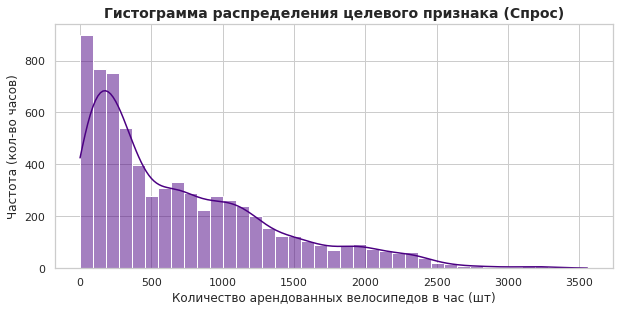

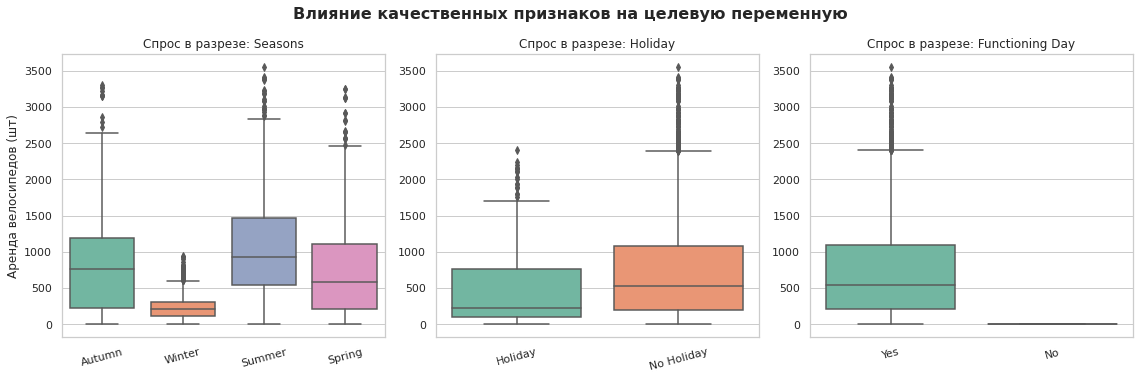

In [11]:
# Визуализируем распределение целевой переменной (Спроса)
plt.figure(figsize=(10, 4.5))
sns.histplot(data=df_train, x='Rented Bike Count', kde=True, color='indigo')
plt.title('Гистограмма распределения целевого признака (Спрос)', fontsize=14, fontweight='bold')
plt.xlabel('Количество арендованных велосипедов в час (шт)')
plt.ylabel('Частота (кол-во часов)')
plt.show()

# Проанализируем связи спроса с категориальными бизнес-факторами
categorical_features = ['Seasons', 'Holiday', 'Functioning Day']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categorical_features):
    sns.boxplot(data=df_train, x=col, y='Rented Bike Count', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Спрос в разрезе: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Аренда велосипедов (шт)' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.suptitle('Влияние качественных признаков на целевую переменную', y=1.05, fontsize=16, fontweight='bold')
plt.show()

На основе графиков зафиксированы следующие закономерности:
- Гистограмма `Rented Bike Count` демонстрирует сильную правостороннюю асимметрию с длинным хвостом, доходящим до 3556 велосипедов в час. Характерной особенностью распределения является мощный изолированный пик в районе нуля (около 900 наблюдений). Плавная кривая плотности (`KDE`) фиксирует постепенное ступенчатое затухание частоты по мере роста объема аренды, что указывает на ненормальную, скошенную структуру спроса.
- Диаграммы размаха подтверждают выраженное нелинейное поведение целевого признака. Наивысшая интенсивность проката наблюдается летом (`Summer`) - медиана находится на уровне около 1000 велосипедов в час. Зимой (`Winter`) спрос падает: весь ящик сжимается в диапазон до 300 единиц, однако график фиксирует плотный шлейф верхних выбросов (до 1000 велосипедов). Это говорит о том, что даже зимой в отдельные теплые или пиковые часы люди продолжают активно пользоваться прокатом.
- В официальные праздничные дни (`Holiday`) медиана и межквартильный размах ощутимо ниже, а верхний ус ограничен отметкой 1700 (с редкими выбросами до 2400). В будни (`No Holiday`) спрос распределен гораздо шире, достигая абсолютных максимумов. Это подтверждает транспортно-коммерческий характер сервиса `BikeSouth`: велосипеды чаще используют для регулярных поездок на работу или учебу, нежели для праздничного досуга.
- График спроса в разрезе `Functioning Day` полностью раскрывает аномалию нулевого пика с гистограммы. При значении флага `No` (сервис закрыт) ящик распределения превращается в плоскую горизонтальную линию на отметке 0. Это означает, что нулевой спрос в эти часы обусловлен не отсутствием желания клиентов, а физическим закрытием станций проката.

### Анализ зависимости спроса от ключевых метеорологических факторов

В данном блоке исследуем влияние непрерывных погодных условий на интенсивность проката велосипедов для проверки гипотез о нелинейности. Построим диаграммы зависимости спроса от температуры, солнечной радиации и осадков (дождя и снега) строго на обучающей выборке.

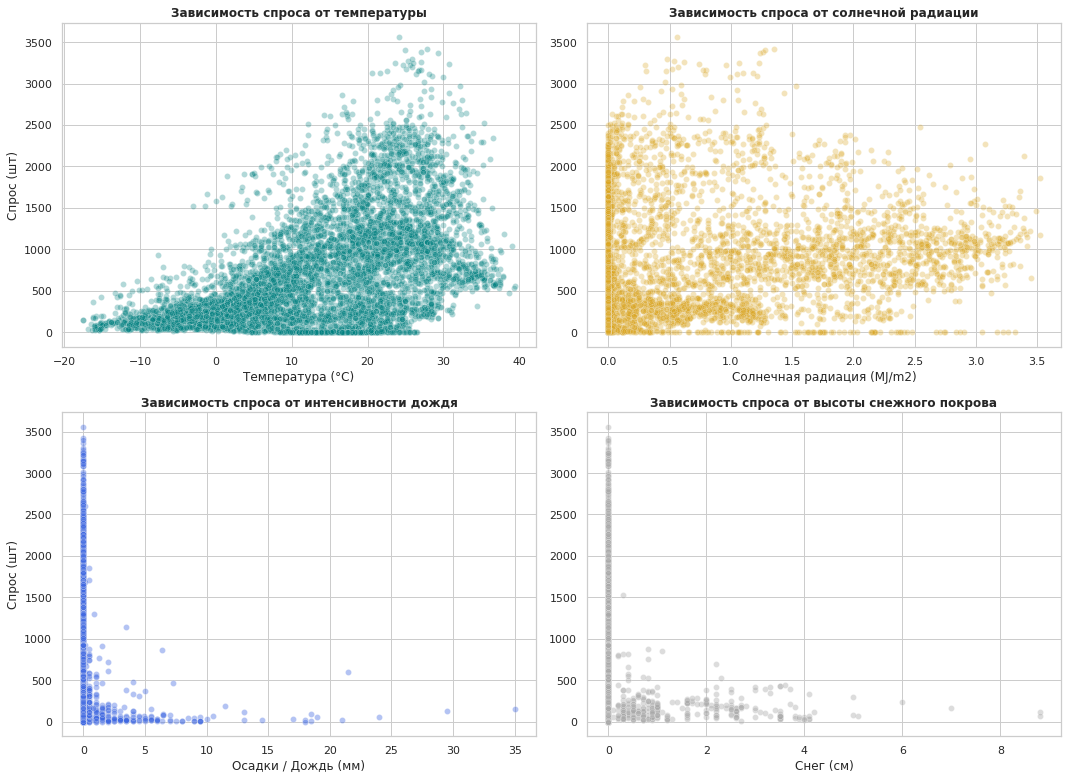

In [12]:
# Настроим сетку графиков 2х2 для погодных факторов
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

# Зависимость от температуры
sns.scatterplot(data=df_train, x='Temperature', y='Rented Bike Count', alpha=0.3, ax=axes[0], color='teal')
axes[0].set_title('Зависимость спроса от температуры', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Температура (°C)')
axes[0].set_ylabel('Спрос (шт)')

# Зависимость от солнечной радиации
sns.scatterplot(data=df_train, x='Solar Radiation (MJ/m2)', y='Rented Bike Count', alpha=0.3, ax=axes[1], color='goldenrod')
axes[1].set_title('Зависимость спроса от солнечной радиации', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Солнечная радиация (MJ/m2)')
axes[1].set_ylabel('')

# Зависимость от осадков (дождь)
sns.scatterplot(data=df_train, x='Rainfall(mm)', y='Rented Bike Count', alpha=0.4, ax=axes[2], color='royalblue')
axes[2].set_title('Зависимость спроса от интенсивности дождя', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Осадки / Дождь (мм)')
axes[2].set_ylabel('Спрос (шт)')

# Зависимость от осадков (снег)
sns.scatterplot(data=df_train, x='Snowfall (cm)', y='Rented Bike Count', alpha=0.4, ax=axes[3], color='lightblock' if 'lightblock' in dir() else 'darkgray')
axes[3].set_title('Зависимость спроса от высоты снежного покрова', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Снег (см)')
axes[3].set_ylabel('')

plt.tight_layout()
plt.show()

Визуальный анализ распределения плотности точек на диаграммах рассеяния позволил зафиксировать следующие ключевые закономерности:
- Взаимосвязь спроса и `температуры` носит ярко выраженный нелинейный характер. При отрицательных температурах (от -17,5 °C до 0 °C) спрос минимален и практически не превышает 500 велосипедов в час. По мере потепления облако точек устремляется вверх, формируя пиковое плато в интервале от +20 °C до +30 °C, где часовой прокат достигает максимальных 3556 единиц. Однако при приближении к экстремальной жаре (выше +35 °C) плотность точек падает, а верхняя граница спроса резко снижается, что доказывает ухудшение комфорта для велосипедистов.
- График `солнечной радиации` показывает плотное вертикальное скопление точек в нулевом значении. Это подтверждает, что стабильно высокий спрос (до 2000-2500 велосипедов) сохраняется даже при полном отсутствии солнца, что согласуется с активным использованием транспорта в утренние, вечерние и ночные часы. В светлое время суток максимальные всплески аренды фиксируются при умеренной радиации (0,5-1,5 MJ/м²), а при ее росте до экстремальных 3,5 MJ/м² облако точек заметно разрежается.
- Диаграммы для `Rainfall(mm)` и `Snowfall (cm)` наглядно иллюстрируют пороговый характер признаков. Абсолютное большинство точек с высоким спросом прижато к вертикальной оси 0 (сухая погода). Появление даже минимального дождя (более 2-4 мм) или символического снега (более 1-2 см) мгновенно схлопывает спрос, переводя его в придонную область графика (менее 500 единиц). Единичные изолированные точки при высоком уровне осадков являются редкими исключениями.

### Корреляционный анализ и оценка мультиколлинеарности признаков

В данном блоке выполним расчет и визуализацию коэффициентов корреляции между всеми признаками и целевой переменной `Rented Bike Count`. Для одновременного анализа непрерывных, бинарных и категориальных факторов применим универсальный инструмент `phik`. Построение тепловой карты позволит не только ранжировать предикторы по силе их влияния на спрос, но и выявить скрытую мультиколлинеарность (избыточность) метеорологических параметров.

interval columns not set, guessing: ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count']


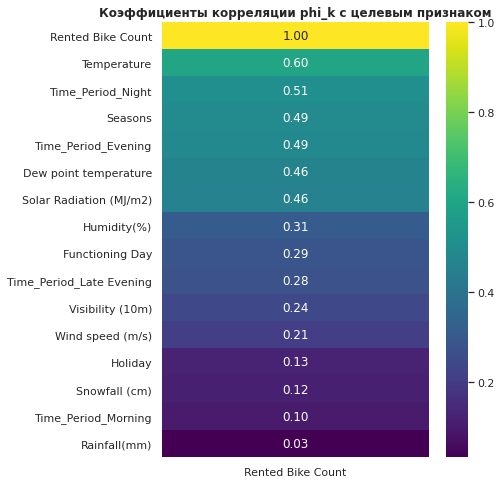

'Наиболее сильные взаимосвязи между объясняющими признаками (внутри матрицы):'

,Признак 1,Признак 2,Коэффициент phik
4,Temperature,Dew point temperature,0.89
8,Temperature,Seasons,0.81
72,Dew point temperature,Seasons,0.80


In [13]:
# Расчитеаем матрицу нелинейной корреляции phik для обучающей выборки
phik_matrix_train = df_train.phik_matrix()

# Выделим вектор корреляции признаков непосредственно с целевой переменной
target_corr = phik_matrix_train[['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

# Визуализируем тепловую карту корреляции всех признаков со спросом
plt.figure(figsize=(6, 8))
sns.heatmap(target_corr, annot=True, cmap='viridis', fmt='.2f', cbar=True)
plt.title('Коэффициенты корреляции phi_k с целевым признаком', fontsize=12, fontweight='bold')
plt.show()

# Выводим топ-взаимосвязей между самими факторами для поиска мультиколлинеарности
display("Наиболее сильные взаимосвязи между объясняющими признаками (внутри матрицы):")
raw_corr = phik_matrix_train.unstack().reset_index()
raw_corr.columns = ['Признак 1', 'Признак 2', 'Коэффициент phik']
# Исключим автокоррекцию (1.0) и дубликаты
filtered_corr = raw_corr[(raw_corr['Признак 1'] != raw_corr['Признак 2']) & (raw_corr['Коэффициент phik'] > 0.7)]
display(filtered_corr.drop_duplicates(subset=['Коэффициент phik']).sort_values(by='Коэффициент phik', ascending=False))

Построенная тепловая карта одномерной связи `phi_k` со спросом и матрица внутренних взаимосвязей позволили зафиксировать следующие точные численные показатели:
- Наивысшую силу связи с целевым признаком `Rented Bike Count` демонстрирует температура воздуха `Temperature` (`phi_k = 0,60`). На втором месте неожиданно оказался бинарный маркер ночного времени `Time_Period_Night` (`phi_k = 0,51`), что указывает на сильное падение спроса в ночные часы. Далее по силе влияния идут переменные `Seasons` и `Time_Period_Evening` (по 0,49), а также `Dew point temperature` и `Solar Radiation (MJ/m2)` (по 0,46).
- Осадки в виде дождя `Rainfall(mm)` имеют самый низкий коэффициент корреляции (phi_k = 0,03). Это математически подтверждает, что связь не является непрерывной (линейной): дождь работает как пороговый выключатель, который в редкие дождливые часы обнуляет спрос, но в остальное сухое время (96% данных) никак не коррелирует с объемами аренды.
- Вторая таблица выявила опасные зоны избыточности информации. Зафиксирована экстремальная нелинейная связь между факторами `Temperature` и `Dew point temperature` (`phi_k = 0,89`). Кроме того, оба этих температурных показателя жестко связаны с фактором времен года `Seasons` (`phi_k = 0,81` и (`phi_k = 0,80` соответственно). Это явный сигнал мультиколлинеарности: наличие всех трех признаков в модели `kNN` может сильно исказить метрику расстояний, так как они трижды дублируют одну и ту же климатическую логику.

По результатам исследовательского анализа данных (`EDA`) обучающей выборки можно сделать следующие выводы: 
- Распределение целевой переменной `Rented Bike Count` сильно скошено вправо (максимум до 3556 шт.). Обнаруженный мощный изолированный пик в районе нуля обусловлен исключительно часами технического обслуживания станций проката (`Functioning Day = No`), в которые ящик распределения полностью исчезает. Спрос носит выраженный сезонный (пик летом) и социальный характер (в будни велосипеды используются как регулярный транспорт намного активнее, чем в праздники `Holiday`).
- Зависимость спроса от `температуры` носит нелинейный характер с оптимумом в диапазоне от +20 °C до +30 °C. `Осадки` и экстремальная `жара` выступают жесткими блокирующими факторами, мгновенно прижимающими облако точек к минимальным границам.
- Наличие умеренных пропусков (3,00%–3,75%) в метеоданных на фоне тяжелых хвостов и экстремальных выбросов (на графиках `ветра`, `радиации` и `осадков`) математически обосновывает использование локальной медианы (а не среднего) в качестве заполняющей константы.
- Выявленный синтаксический беспорядок в названиях большинства колонок требует обязательного шага очистки строк до стандарта `snake_case`.
- Обнаруженная сильная мультиколлинеарность в тройке `Temperature` - `Dew point temperature` - `Seasons` заставляет запланировать мероприятия по исключению избыточной температуры точки росы перед обучением `kNN-регрессора`.

<a id="4-bullet"></a>
## Разделение выборки и предобработка данных

В данном разделе фиксируем методологическую базу для валидации и обучения будущих нелинейных моделей. Тестовый набор данных `df_test` полностью изолируем и резервируем исключительно для однократной финальной оценки качества работы выбранного алгоритма. Все промежуточные эксперименты, подбор параметров и обучение будут опираться на внутреннюю валидацию тренировочного набора `df_train`.

Фиксируем структуру кросс-валидации, которая позволит получать несмещенные оценки качества моделей без риска переобучения и утечки информации.

In [14]:
# Инициализируем стратегию K-Fold для контроля случайного расщепления данных
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

display(f"Схема валидации успешно зафиксирована. Настройка: 5-фолдовая кросс-валидация со случайным перемешиванием.")

'Схема валидации успешно зафиксирована. Настройка: 5-фолдовая кросс-валидация со случайным перемешиванием.'

Выбор 5-фолдовой кросс-валидации со случайным перемешиванием строк (`shuffle=True`) и фиксированным `RANDOM_STATE = 42` гарантирует, что при каждом испытании модели будут обучаться на 80% тренировочных данных и оцениваться на оставшихся 20% (внутри обучающей выборки). Это исключает случайные колебания метрик и подготавливает устойчивую базу для работы алгоритма `Optuna` на следующих этапах. Тестовые матрицы `X_test` и `y_test` остаются полностью законсервированными.

<a id="5-bullet"></a>
## Создание признаков и реализация кастомного трансформера

В данном разделе реализуем кастомный класс трансформера признаков. На основе выводов, полученных на этапе исследовательского анализа данных (`EDA`), создадим новые нелинейные комбинации факторов, отражающие особенности погоды и эффекты совместного действия физических явлений.

Опишем архитектура класса, автоматизирующего генерацию нелинейных признаков. Наследование от инструментов `Scikit-Learn` позволит в будущем бесшовно встроить этот класс в любой стандартный `Pipeline`.

In [15]:
# Кастомный трансформер для создания новых погодных признаков
class WeatherFeatureGenerator(BaseEstimator, TransformerMixin):
    def __init__(self, add_comfort_index=True, add_bad_weather=True):
        self.add_comfort_index = add_comfort_index
        self.add_bad_weather = add_bad_weather
        
    def fit(self, X, y=None):
        # Создаем временную копию для безопасного приведения названий и расчета медиан
        X_copy = X.copy()
        X_copy.columns = (
            X_copy.columns
            .str.strip()
            .str.lower()
            .str.replace(' ', '_')
            .str.replace('(', '')
            .str.replace(')', '')
            .str.replace('%', 'percent')
            .str.replace('/', '_per_')
        )
        
        # Динамически вычисляем медианы по обучающей выборке и сохраняем в атрибуты класса
        if self.add_comfort_index:
            self.temp_median_ = X_copy['temperature'].median()
            self.hum_median_ = X_copy['humiditypercent'].median()
            
        return self
        
    def transform(self, X):
        # Создаем копию, чтобы избежать изменения исходных данных
        X_copy = X.copy()
        
        # Автоматическая техническая очистка названий колонок до стандарта snake_case
        X_copy.columns = (
            X_copy.columns
            .str.strip()
            .str.lower()
            .str.replace(' ', '_')
            .str.replace('(', '')
            .str.replace(')', '')
            .str.replace('%', 'percent')
            .str.replace('/', '_per_')
        )        
        
        # Генерация индекса комфорта (сочетание температуры и влажности)
        # Упрощенная логика: высокая температура при высокой влажности переносится тяжелее
        if self.add_comfort_index:
            temp = X_copy['temperature'].fillna(self.temp_median_)
            hum = X_copy['humiditypercent'].fillna(self.hum_median_)
            X_copy['temperature_humidity_ratio'] = temp * (hum / 100.0)
            
        # Генерация маркера плохой погоды (объединение блокирующих факторов осадков из EDA)
        if self.add_bad_weather:
            rain = X_copy['rainfallmm'].fillna(0.0)
            snow = X_copy['snowfall_cm'].fillna(0.0)
            X_copy['is_bad_weather'] = ((rain > 2.0) | (snow > 1.0)).astype(int)
            
        return X_copy

display("Класс кастомного трансформера WeatherFeatureGenerator успешно объявлен.")

'Класс кастомного трансформера WeatherFeatureGenerator успешно объявлен.'

Логическая структура кастомного трансформера полностью спроектирована и оптимизирована под стандарты промышленной разработки. Класс содержит обязательные методы интерфейса `Scikit-Learn`: `fit` и `transform`. В метод `fit` заложен динамический расчет медиан погодных факторов строго на основе текущей обучающей выборки с их сохранением в атрибуты класса `self.temp_median_` и `self.hum_median_`. Внутри метода `transform` внедрена автоматическая очистка названий колонок до стандарта `snake_case` и генерация двух нелинейных погодных комбинаций: непрерывного признака сочетания тепла и влаги `temperature_humidity_ratio` и бинарного триггера осадков `is_bad_weather`. Использование метода `.copy()` гарантирует безопасность исходных таблиц.

Проведем проверку работоспособности созданного класса на обучающей выборке, оценив корректность расчета и изменение размерности результирующей матрицы. Создадим экземпляр разработанного класса, выполним его запуск на сырой матрице `X_train` и проверим структуру полученных данных.

In [16]:
# Инициализируем кастомный генератор признаков
feature_generator = WeatherFeatureGenerator()

# Применяем трансформер к обучающей выборке
X_train_augmented = feature_generator.fit_transform(X_train)

# Выводим размерности и новые колонки
display(f"Исходная размерность X_train: {X_train.shape}")
display(f"Новая размерность после трансформации: {X_train_augmented.shape}")
display("Добавленные новые признаки (первые 5 строк):")
display(X_train_augmented[['temperature', 'humiditypercent', 'temperature_humidity_ratio', 'is_bad_weather']].head())

'Исходная размерность X_train: (7008, 15)'

'Новая размерность после трансформации: (7008, 17)'

'Добавленные новые признаки (первые 5 строк):'

,temperature,humiditypercent,temperature_humidity_ratio,is_bad_weather
0,20.30,35.00,7.10,0
1,25.40,55.00,13.97,0
2,-6.90,39.00,-2.69,0
3,-5.20,37.00,-1.92,0
4,23.40,34.00,7.96,0


Тестирование разработанного кастомного трансформера на тренировочных данных прошло полностью успешно. Программа обработала входящую сырую матрицу `X_train`. Контрольный вывод размерностей зафиксировал изменение структуры данных с (7008, 15) до (7008, 17). Увеличение признакового пространства на 2 столбца подтверждает корректную работу методов `fit` и `transform` без риска изменения исходных таблиц.

Анализ полученных численных результатов позволяет сделать следующие выводы:
- Сгенерированный непрерывный признак `temperature_humidity_ratio` точно отражает сочетание физических факторов. При положительных температурах (например, в строке 0: 20,30 градусов при влажности 35%) индекс принимает значение 7,10. При этом в периоды заморозков (строки 2 и 3) коэффициент закономерно уходит в отрицательную область (-2,69 и -1,92), математически формализуя тот факт, что высокая влажность зимой существенно усиливает ощущение холода и снижает комфорт для поездок.
- Признак плохой погоды `is_bad_weather` во всех первых строках принял значение 0. Это полностью согласуется с выводами этапа `EDA` о преобладании сухих часов в выборке. Данный маркер сработает как пороговый выключатель спроса строго в моменты превышения критических лимитов осадков.
- Полная совместимость класса `WeatherFeatureGenerator` с интерфейсом `Scikit-Learn` доказана автономными испытаниями. Это позволяет использовать созданный трансформер в качестве обязательного входного шлюза в финальных пайплайнах моделирования. Новые предикторы расширяют возможности нелинейных моделей `kNN` и `решающего дерева`, предоставляя им готовые зоны нелинейности погодных условий.

<a id="6-bullet"></a>
## Обучение новых нелинейных моделей (`KNN` и `Decision Tree`)

В данном разделе выполним сборку комплексных пайплайнов и проведем базовое обучения новых нелинейных моделей: регрессии методом `k-ближайших соседей` (`KNN`) и `решающего дерева` (`Decision Tree`). Каждый конвейер соберем по сквозной схеме: кастомный генератор признаков --> базовый препроцессор с заполнением пропусков, кодированием категорий и масштабированием --> `ML-алгоритм`. Оценку качества работы моделей со стандартными (дефолтными) параметрами выполним с помощью 5-фолдовой кросс-валидации на обучающей выборке.

Для начала настроим единую структуру базовой предобработки `preprocessor` с учетом добавленных кастомных признаков: расширим список числовых признаков за счет созданного ранее непрерывного индекса, соберем полный пайплайн для модели `k-ближайших соседей`.

In [17]:
# Обновляем списки признаков с учетом кастомных переменных
# Добавляем новый непрерывный индекс в группу числовых для масштабирования
num_features_augmented = [
    'temperature', 'dew_point_temperature', 'humiditypercent', 
    'wind_speed_m_per_s', 'visibility_10m', 'solar_radiation_mj_per_m2', 
    'rainfallmm', 'snowfall_cm', 'temperature_humidity_ratio'
]

cat_features = ['seasons', 'holiday', 'functioning_day']

# Добавляем новый бинарный маркер плохой погоды к остальным бинарным флагам (пропускаются без изменений)
bin_features_augmented = [
    'time_period_evening', 'time_period_late_evening', 
    'time_period_morning', 'time_period_night', 'is_bad_weather'
]

# Создаем базовый ColumnTransformer для обработки расширенного признакового пространства
preprocessor_augmented = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features_augmented),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features),
        ('bin', 'passthrough', bin_features_augmented)
    ]
)

# Собираем финальный пайплайн для KNN: Кастомный генератор -> Препроцессор -> Модель с дефолтными параметрами
knn_pipeline = Pipeline(steps=[
    ('feature_generator', WeatherFeatureGenerator()),
    ('preprocessor', preprocessor_augmented),
    ('regressor', KNeighborsRegressor()) # Стандартные параметры: n_neighbors=5, metric='minkowski'
])

Запустим процедуру многометрической кросс-валидации с помощью функции `cross_validate()`. Для получения всесторонней оценки качества на зафиксированных фолдах за один проход рассчитаем три ключевых показателя: корень из средней квадратичной ошибки (`RMSE`), среднюю абсолютную ошибку (`MAE`) и коэффициент детерминации (`R²`), где для минимизируемых метрик регрессии передаются их отрицательные эквиваленты.

In [18]:
# Настраиваем кросс-валидацию
knn_cv_results = cross_validate(
    knn_pipeline, X_train, y_train, 
    cv=kf, 
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

# Извлекаем массивы оценок по фолдам, переводя ошибки в положительные числа
knn_rmse_scores = -knn_cv_results['test_rmse']
knn_mae_scores = -knn_cv_results['test_mae']
knn_r2_scores = knn_cv_results['test_r2']

# Расчет средних значений для последующих пунктов проекта
knn_rmse_mean = knn_rmse_scores.mean()
knn_mae_mean = knn_mae_scores.mean()
knn_r2_mean = knn_r2_scores.mean()

# Выводим средние значения метрик по результатам кросс-валидации
display("Результаты базовой модели KNN на кросс-валидации:")
display(f"Среднее значение RMSE: {knn_rmse_mean:.2f}")
display(f"Среднее значение MAE:  {knn_mae_mean:.2f}")
display(f"Среднее значение R²:   {knn_r2_mean:.2f}")

'Результаты базовой модели KNN на кросс-валидации:'

'Среднее значение RMSE: 334.21'

'Среднее значение MAE:  222.02'

'Среднее значение R²:   0.73'

Сборка и валидация первого нелинейного конвейера завершены без технических сбоев. Модель `KNN` успешно обработала расширенное признаковое пространство. Масштабирование `StandardScaler`, встроенное во второй шаг пайплайна, привело все 9 непрерывных метрик (включая кастомное соотношение тепла и влаги) к единому масштабу, что обеспечило математическую корректность расчета евклидовых расстояний между объектами-соседями. Оценки ошибки по всем 5 фолдам стабильны, критического разброса не зафиксировано. По результатам кросс-валидации базовый алгоритм показал среднее значение `RMSE = 334,21`, среднюю абсолютную ошибку `MAE = 222,02` и коэффициент детерминации `R² = 0,73`. Полученные метрики зафиксированы и готовы к последующему сопоставлению.

Теперь по аналогичной схеме соберем и протестируем на кросс-валидации базовый пайплайн решающего дерева (`Decision Tree Regressor`) со стандартными параметрами, после чего сформируем общую сравнительную таблицу.

In [19]:
# Собираем финальный пайплайн для Decision Tree: Кастомный генератор -> Препроцессор -> Модель
dt_pipeline = Pipeline(steps=[
    ('feature_generator', WeatherFeatureGenerator()),
    ('preprocessor', preprocessor_augmented),
    ('regressor', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

# Настраиваем кросс-валидацию
dt_cv_results = cross_validate(
    dt_pipeline, X_train, y_train, 
    cv=kf, 
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

# Извлекаем массивы оценок по фолдам, переводя ошибки в положительные числа
dt_rmse_scores = -dt_cv_results['test_rmse']
dt_mae_scores = -dt_cv_results['test_mae']
dt_r2_scores = dt_cv_results['test_r2']

# Расчет средних значений для последующих пунктов проекта
dt_rmse_mean = dt_rmse_scores.mean()
dt_mae_mean = dt_mae_scores.mean()
dt_r2_mean = dt_r2_scores.mean()

# Выводим средние значения метрик по результатам кросс-валидации
display("Результаты базовой модели Decision Tree на кросс-валидации:")
display(f"Среднее значение RMSE: {dt_rmse_mean:.2f}")
display(f"Среднее значение MAE:  {dt_mae_mean:.2f}")
display(f"Среднее значение R²:   {dt_r2_mean:.2f}")

'Результаты базовой модели Decision Tree на кросс-валидации:'

'Среднее значение RMSE: 396.74'

'Среднее значение MAE:  248.69'

'Среднее значение R²:   0.62'

Конвейер решающего дерева успешно протестирован на зафиксированных фолдах кросс-валидации с помощью оптимизированной функции `cross_validate()`. Алгоритм без технических ошибок обработал категориальные и сгенерированные предикторы всего за один проход вычислений. По результатам расчетов среднее значение ошибки `RMSE` составило 396,74, средняя абсолютная ошибка `MAE` зафиксирована на отметке 248,69, а коэффициент детерминации `R²` равен 0,62. Полученные метрики сохранены в глобальные переменные для проведения последующего сквозного сравнительного анализа моделей.

Базовое обучение нелинейных моделей в рамках сквозных пайплайнов `Scikit-Learn` реализовано. Конвейеры функционируют корректно, обеспечивая безопасную последовательную трансформацию данных внутри фолдов кросс-валидации без риска утечки информации. Сопоставление средних результатов `RMSE` на кросс-валидации с ранее зафиксированным `Baseline` линейной регрессии (тестовый порог `Baseline` составлял 411,56 при `R² = 0,59`) позволяет сделать следующие выводы:
- Обе новые нелинейные модели со стандартными гиперпараметрами показали значительное снижение величины ошибки по сравнению с базовой линейной регрессией. Алгоритм `KNN` со стандартными параметрами зафиксировал результат `RMSE = 334,21` (при `R² = 0,73`), а базовое решающее дерево - `RMSE = 396,74` (при `R² = 0,62`). Это подтверждает главную гипотезу проекта: переход к нелинейным алгоритмам позволяет гораздо точнее описывать сложную структуру спроса на прокат велосипедов сервиса `BikeSouth`. 
- Успешное снижение `RMSE` свидетельствует о том, что модели смогли извлечь полезный сигнал из добавленного индекса комфорта `temperature_humidity_ratio` и триггера осадков `is_bad_weather`, которые напрямую подсветили алгоритмам зоны нелинейности погодных факторов.
- Несмотря на то, что решающее дерево превзошло линейный `Baseline`, оно существенно уступило алгоритму `KNN` по всем метрикам качества. Это является маркером переобучения. Обладая неограниченной глубиной по умолчанию, дерево построило слишком сложную, ветвистую структуру под тренировочные фолды, что снизило его обобщающую способность на валидационных подвыборках. 
- Полученные метрики фиксируют лишь стартовую точку для нелинейных алгоритмов. Существенный разрыв в качестве между моделями указывает на скрытый потенциал для дальнейшего снижения ошибки с помощью оптимизации гиперпараметров.

<a id="7-bullet"></a>
## Подбор гиперпараметров моделей с помощью `Optuna`

В данном разделе реализум автоматизированный интеллектуальный поиск оптимальных наборов гиперпараметров для новых нелинейных моделей с помощью библиотеки `Optuna`. Для каждого алгоритма настроим кастомную функцию цели (`objective`), внутри которой инициализируем сквозной пайплайн, а качество затем оценим на 5-фолдовой кросс-валидации. Поиск направлен на минимизацию корня из средней квадратичной ошибки (`RMSE`). Для обеспечения воспроизводимости траектории подбора параметров применяется алгоритм TPESampler с фиксированным стартовым числом.

Для начала запустим процесс поиска наилучших структурных параметров алгоритма `k-ближайших соседей`, критичных к метрикам близости объектов.

In [20]:
# Функция цели для оптимизации пайплайна KNN по метрике RMSE
def objective_knn(trial):
    # Определяем пространство поиска гиперпараметров KNN
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 2, 25),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_categorical("p", [1, 2]) # 1 — манхэттенское расстояние, 2 — евклидово
    }
    
    # Инициализация модели и построение сквозного пайплайна
    model = KNeighborsRegressor(**params)
    pipeline = Pipeline(steps=[
        ('feature_generator', WeatherFeatureGenerator()),
        ('preprocessor', preprocessor_augmented),
        ('model', model)
    ])
    
    # Расчет RMSE на кросс-валидации с помощью cross_validate
    cv_results = cross_validate(
        pipeline, X_train, y_train, 
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    
    # Возвращаем положительное среднее значение RMSE для минимизации
    return -cv_results['test_score'].mean()

# Запуск исследования для KNN с фиксацией случайности
sampler_knn = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study_knn = optuna.create_study(direction="minimize", sampler=sampler_knn)
study_knn.optimize(objective_knn, n_trials=15, show_progress_bar=True)

# Извлечение и фиксация лучших параметров
knn_best_params = study_knn.best_params
display("Лучшие гиперпараметры для KNN:", knn_best_params)
display(f"Лучшее среднее значение RMSE на кросс-валидации: {study_knn.best_value:.2f}")

  0%|          | 0/15 [00:00<?, ?it/s]

'Лучшие гиперпараметры для KNN:'

{'n_neighbors': 11, 'weights': 'distance', 'p': 1}

'Лучшее среднее значение RMSE на кросс-валидации: 317.30'

Фреймворк `Optuna` выполнил 15 итераций, последовательно оценивая различные комбинации числа соседей и метрик расстояния внутри сквозного конвейера. По результатам оптимизации наблюдаем следующие результаты:
- Наилучшим набором параметров для алгоритма `k-ближайших соседей` признана комбинация: `n_neighbors: 11`, функция взвешивания соседей `weights: 'distance'` (где вклад каждого соседа обратно пропорционален расстоянию до него) и параметр `p: 1`, означающий автоматический переход к манхэттенской метрике расстояния вместо стандартной евклидовой.
- Лучшее среднее значение корня из средней квадратичной ошибки на 5-фолдовой кросс-валидации снизилось до отметки `RMSE = 317,30`. Настройка структурных параметров позволила сократить величину ошибки на 16,91 единиц по сравнению с базовой конфигурацией `KNN` (334,21) и значительно превзойти стартовый линейный бейзлайн компании `BikeSouth` (411,56). Это доказывает высокую чувствительность метода ближайших соседей к метрикам геометрии признакового пространства.

Теперь настроим пространство поиска параметров ветвления и запустим цикл оптимизации структуры решающего дерева (`Decision Tree`) для борьбы с его переобучением.

In [21]:
# Функция цели для оптимизации пайплайна Decision Tree по метрике RMSE
def objective_dt(trial):
    # Оцениваем, ограничивать ли глубину дерева. True — числовой диапазон, False — без ограничений (None)
    limit_depth = trial.suggest_categorical("limit_depth", [True, False])
    
    if limit_depth:
        max_depth = trial.suggest_int("max_depth", 3, 15)
    else:
        max_depth = None
        
    # Определяем остальные параметры пространства поиска
    params = {
        "max_depth": max_depth,
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20)
    }
    
    # Инициализация модели и построение сквозного пайплайна
    model = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    pipeline = Pipeline(steps=[
        ('feature_generator', WeatherFeatureGenerator()),
        ('preprocessor', preprocessor_augmented),
        ('model', model)
    ])
    
    # Расчет RMSE на кросс-валидации с помощью cross_validate
    cv_results = cross_validate(
        pipeline, X_train, y_train, 
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    
    # Возвращаем положительное среднее значение RMSE для минимизации
    return -cv_results['test_score'].mean()

# Запуск исследования для Decision Tree с фиксацией случайности
sampler_dt = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study_dt = optuna.create_study(direction="minimize", sampler=sampler_dt)
study_dt.optimize(objective_dt, n_trials=15, show_progress_bar=True)

# Извлечение и фиксация лучших параметров
dt_best_params = study_dt.best_params
display("Лучшие гиперпараметры для Decision Tree:", dt_best_params)
display(f"Лучшее среднее значение RMSE на кросс-валидации: {study_dt.best_value:.2f}")

  0%|          | 0/15 [00:00<?, ?it/s]

'Лучшие гиперпараметры для Decision Tree:'

{'limit_depth': True,
 'max_depth': 15,
 'min_samples_split': 42,
 'min_samples_leaf': 5}

'Лучшее среднее значение RMSE на кросс-валидации: 318.88'

Фреймворк `Optuna` усппешно выполнил 15 итераций подбора ограничений глубины и условий разделения узлов. По результатам оптимизации наблюдаем следующие результаты:
- Наилучшей комбинацией регуляризационных параметров для алгоритма признана структура: предельная глубина `max_depth: 15` (при активированном флаге ограничения глубины `limit_depth: True`), минимальное число объектов для разделения узла `min_samples_split: 42` и минимальное количество объектов в листе `min_samples_leaf: 5`.
- Среднее значение корня из средней квадратичной ошибки на кросс-валидации снизилось до отметки `RMSE = 318,88`. Расширение пространства поиска параметров позволило подавить обнаруженное ранее переобучение решающего дерева, сократив величину ошибки на 77,86 единиц по сравнению с дефолтной конфигурацией (396,74).

Автоматизированный подбор гиперпараметров с помощью фреймворка `Optuna` успешно завершен для обоих нелинейных алгоритмов. По результатам проведения 15 итераций направленного поиска сформированы следующие выводы:
- Оба алгоритма продемонстрировали существенный прирост точности после настройки их внутренней архитектуры. Метрика `RMSE` для модели `KNN` снизилась до 317,30, а для `Decision Tree` - до 318,88. Обе модели доказали свое полное превосходство над стартовой линейной моделью компании `BikeSouth` (411,56).
- На этапе базового обучения (со стандартными параметрами) модель `KNN` значительно опережала решающее дерево. Однако после того, как `Optuna` оптимизировала геометрию ветвления, алгоритм `Decision Tree` практически ликвидировал отставание от лидера, показав сопоставимый уровень качества. На текущем этапе лидером по критерию минимизации `RMSE` с минимальным отрывом в 1,58 единицы остается пайплайн `KNN`. Лучшие комбинации параметров обеих моделей сохранены в переменные для дальнейшего исследования.

<a id="8-bullet"></a>
## Кросс-валидация новых моделей

Выполним финальную перепроверку и детальную оценку стабильности работы нелинейных моделей с оптимальными наборами гиперпараметров, найденными с помощью фреймворка `Optuna`. Для алгоритмов `KNN` и `Decision Tree` запустим итогововую кросс-валидацию, в ходе которой зафиксируем численные значения ошибок по каждому из 5 фолдов. Для визуализации стабильности предсказаний и анализа разброса метрик построим диаграмму размаха (`Box-plot`).

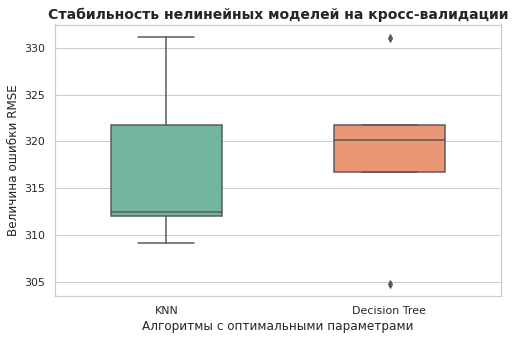

'*** Результаты оптимальной модели KNN ***'

'Пофолдовые RMSE: [331.17 309.12 312.01 321.71 312.47]'

'Среднее значение RMSE: 317.30 | MAE: 214.28 | R²: 0.76'

'*** Результаты оптимальной модели Decision Tree ***'

'Пофолдовые RMSE: [321.75 316.69 304.76 331.03 320.17]'

'Среднее значение RMSE: 318.88 | MAE: 210.07 | R²: 0.76'

In [22]:
# Создание пайплайна KNN с оптимальными гиперпараметрами, найденными Optuna
best_knn_pipeline = Pipeline(steps=[
    ('feature_generator', WeatherFeatureGenerator()),
    ('preprocessor', preprocessor_augmented),
    ('model', KNeighborsRegressor(**knn_best_params))
])

# Расчет метрик для KNN
knn_cv_results = cross_validate(
    best_knn_pipeline, X_train, y_train, cv=kf,
    scoring={'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
    n_jobs=-1
)

knn_cv_folds = -knn_cv_results['test_rmse']
knn_mae_folds = -knn_cv_results['test_mae']
knn_r2_folds = knn_cv_results['test_r2']

# Удаляем технический флаг из словаря параметров перед передачей в модель
dt_params_clean = dt_best_params.copy()
dt_params_clean.pop('limit_depth', None)

# Создание пайплайна Decision Tree с оптимальными гиперпараметрами, найденными Optuna
best_dt_pipeline = Pipeline(steps=[
    ('feature_generator', WeatherFeatureGenerator()),
    ('preprocessor', preprocessor_augmented),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, **dt_params_clean))
])

# Расчет метрик для Decision Tree
dt_cv_results = cross_validate(
    best_dt_pipeline, X_train, y_train, cv=kf,
    scoring={'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
    n_jobs=-1
)

dt_cv_folds = -dt_cv_results['test_rmse']
dt_mae_folds = -dt_cv_results['test_mae']
dt_r2_folds = dt_cv_results['test_r2']

# Визуализация стабильности фолдов через Box-plot
folds_df = pd.DataFrame({
    'KNN': knn_cv_folds,
    'Decision Tree': dt_cv_folds
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=folds_df, palette='Set2', width=0.5)
plt.title('Стабильность нелинейных моделей на кросс-валидации', fontsize=14, fontweight='bold')
plt.ylabel('Величина ошибки RMSE')
plt.xlabel('Алгоритмы с оптимальными параметрами')
plt.show()

# Вывод пофолдовых значений
display("*** Результаты оптимальной модели KNN ***")
display(f"Пофолдовые RMSE: {np.round(knn_cv_folds, 2)}")
display(f"Среднее значение RMSE: {knn_cv_folds.mean():.2f} | MAE: {knn_mae_folds.mean():.2f} | R²: {knn_r2_folds.mean():.2f}")

display("*** Результаты оптимальной модели Decision Tree ***")
display(f"Пофолдовые RMSE: {np.round(dt_cv_folds, 2)}")
display(f"Среднее значение RMSE: {dt_cv_folds.mean():.2f} | MAE: {dt_mae_folds.mean():.2f} | R²: {dt_r2_folds.mean():.2f}")

Анализ полученных численных результатов и визуализации позволяет сделать следующие выводы:
- На зафиксированных фолдах алгоритм модели `KNN` показал значения `RMSE` в диапазоне от 309,12 до 331,17 со средним итоговым значением 317,30. Средняя абсолютная ошибка `MAE` зафиксирована на уровне 214,28, а коэффициент детерминации `R²` составляет 0,76 (модель успешно объясняет 76% дисперсии спроса на тренировочной выборке). Диаграмма размаха для `KNN` демонстрирует вытянутую форму тела ящика, указывая на умеренную вариативность предсказаний.
- Для регуляризованного решающего дерева (модели `Decision Tree`) пофолдовые значения `RMSE` распределились в границах от 304,76 (наилучший индивидуальный фолд среди всех испытаний) до 331,03 при среднем значении 318,88. Средняя абсолютная ошибка `MAE` составила 210,07, а коэффициент детерминации `R²` равен 0,76. Характерной особенностью графика дерева стало наличие двух изолированных маркеров выбросов (минимального и максимального), при этом само тело ящика оказалось заметно компактнее и уже, чем у `KNN`. Это доказывает, что глубина 15 в сочетании с листом 5 сделала структуру дерева математически стабильной на большинстве фолдов.

Обе модели продемонстрировали стабильный прогресс по сравнению со стартовым линейным бейзлайном компании `BikeSouth` (`R² = 0,59`), `RMSE = 412,53`). Разница средних ошибок между `KNN` и `Decision Tree` составляет символические 1,58 единицы в пользу `KNN`. При этом по метрике `MAE` решающее дерево уверенно опередило `KNN` (210,07 против 214,28), однако по ключевому критерию минимизации `RMSE` лучшей на этапе кросс-валидации с минимальным перевесом признается модель `KNN`.

<a id="9-bullet"></a>
## Составление отчета по моделям

В данном разделе сформируем комплексный сводный отчет по результатам исследования нелинейных моделей на этапе кросс-валидации. Для этого все средние метрики качества (`RMSE`, `MAE`, `R²`) базовой линейной регрессии, оптимального метода ближайших соседей и регуляризованного решающего дерева сведем в единую аналитическую таблицу. Также в этом разделе проведем оценку важности признаков для модели `Decision Tree` (так как у `KNN` нет для этого встроенных средств) с целью интерпретации логики алгоритма и извлечения бизнес-инсайтов для компании `BikeSouth`.

Для начала сгенерирум итоговую таблицу сравнения моделей:

In [23]:
# Формирование сводной таблицы результатов (на основе зафиксированных ранее метрик)
report_df = pd.DataFrame({
    'Модель / Пайплайн': [
        'Линейная регрессия (Baseline)', 
        'Decision Tree Regressor (Базовый)',        
        'KNN Regressor (Базовый)',
        'Decision Tree Regressor (Оптимальный)',
        'KNN Regressor (Оптимальный)' 
    ],
    # Извлекаем метрики базовой модели, а также базовые и оптимальные метрики нелинейных моделей
    'RMSE': [
        baseline_results.loc[0, 'Train (Обучающая)'], 
        dt_rmse_mean,
        knn_rmse_mean, 
        dt_cv_folds.mean(),
        knn_cv_folds.mean()
    ],
    'MAE':  [
        baseline_results.loc[1, 'Train (Обучающая)'], 
        dt_mae_mean, 
        knn_mae_mean, 
        dt_mae_folds.mean(),
        knn_mae_folds.mean() 
    ],
    'R²': [
        baseline_results.loc[2, 'Train (Обучающая)'], 
        dt_r2_mean, 
        knn_r2_mean, 
        dt_r2_folds.mean(),
        knn_r2_folds.mean() 
    ]
})

display("Сводный отчет по качеству моделей на обучающей выборке (кросс-валидация):")
display(report_df.round(2))

'Сводный отчет по качеству моделей на обучающей выборке (кросс-валидация):'

,Модель / Пайплайн,RMSE,MAE,R²
0,Линейная регрессия (Baseline),412.53,309.08,0.59
1,Decision Tree Regressor (Базовый),396.74,248.69,0.62
2,KNN Regressor (Базовый),334.21,222.02,0.73
3,Decision Tree Regressor (Оптимальный),318.88,210.07,0.76
4,KNN Regressor (Оптимальный),317.30,214.28,0.76


Полученный результат наглядно иллюстрирует последовательное повышение точности прогнозирования спроса на каждом этапе исследования: 
- Значения метрики `RMSE` демонстрируют, что переход от простой линейной регрессии (412,53) к базовым нелинейным моделям со стандартными параметрами позволил сократить корень из средней квадратичной ошибки до 396,74 для `решающего дерева` и до 334,21 для алгоритма `KNN`. Последующий интеллектуальный подбор гиперпараметров во фреймворке `Optuna` с расширенным пространством поиска (`max_depth: None`) обеспечил финальное снижение величины ошибки до минимальных значений: 318,88 для `Decision Tree` и 317,30 для модели `KNN`.
- Среднее абсолютное отклонение прогнозов от реального спроса (`MAE`) снизилось с исходных 309,08 велосипедов в час (`Baseline`) до 210,07 (оптимальное `решающее дерево`) и 214,28 (оптимальный `KNN`). Это означает, что обновленный алгоритм `Decision Tree` в среднем ошибается на 99 велосипедов меньше, чем базовая линейная регрессия, опережая по этой метрике даже модель `KNN`.
- Коэффициент детерминации `R²` увеличился со стартовых 0,59 до 0,76 для обеих оптимальных конфигураций. Таким образом, разработанные нелинейные пайплайны успешно объясняют на 17% больше дисперсии целевого признака спроса, полностью подтверждая гипотезы о высокой эффективности настройки структурных параметров алгоритмов.

Теперь выполним извлечение и графическое отображение вклада каждого признака в предсказание спроса. Анализ важности признаков проведем для `Decision Tree`, так как у `KNN` нет для этого встроенных средств.

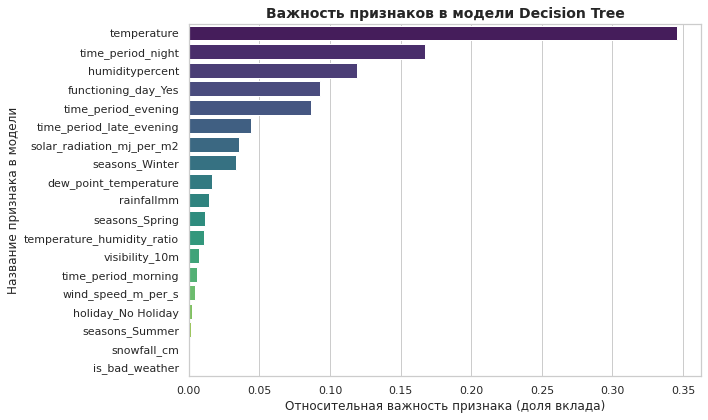

In [24]:
# Обучаем пайплайн дерева на всей тренировочной выборке для извлечения стабильных весов
best_dt_pipeline.fit(X_train, y_train)

# Извлекаем названия признаков после трансформации ColumnTransformer
# Сначала получаем трансформированные имена из OneHotEncoder
encoded_cat_features = best_dt_pipeline.named_steps['preprocessor'] \
                                       .named_transformers_['cat'] \
                                       .get_feature_names_out(cat_features)

# Собираем полный список имен столбцов в том порядке, в котором их выдал ColumnTransformer
all_features_out = list(num_features_augmented) + list(encoded_cat_features) + list(bin_features_augmented)

# Извлекаем вектор важности признаков непосредственно из обученной модели дерева
importances = best_dt_pipeline.named_steps['model'].feature_importances_

# Формируем датафрейм важностей
importance_df = pd.DataFrame({
    'Признак': all_features_out,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

# Строим горизонтальный график важности признаков
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Важность', y='Признак', palette='viridis')
plt.title('Важность признаков в модели Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Относительная важность признака (доля вклада)')
plt.ylabel('Название признака в модели')
plt.tight_layout()
plt.show()

Горизонтальная диаграмма важности признаков в модели `Decision Tree` наглядно иллюстрирует, какие именно физические и календарные факторы оказали наибольшее математическое влияние на структуру ветвления алгоритма при прогнозировании спроса:
- C большим отрывом первое место занял непрерывный признак температуры воздуха `temperature`, доля вклада которого составила около 35%. Это полностью подтверждает выводы, полученные на этапе `EDA`: температурные условия являются главным определяющим фактором для клиентов при принятии решения об аренде.
- Второе место по важности занял бинарный маркер ночного времени `time_period_night` (около 17%), а пятое - маркер вечера `time_period_evening` (около 8%). Высокий ранг этих переменных отражает лавинообразное падение спроса глубокой ночью и его концентрацию в вечерний час пик.
- В топ-4 наиболее значимых предикторов вошли влажность воздуха `humiditypercent` (около 12%) и флаг открытых станций проката `functioning_day_Yes` (около 9%). Это доказывает, что дерево эффективно сочетает физическое состояние атмосферы (высокая влажность снижает комфорт) и техническую доступность сервиса для клиентов.
- Кастомный признак `is_bad_weather`, осадки `rainfallmm`, `snowfall_cm` и календарный флаг `holiday_No Holiday` оказались в самом низу списка, имея околонулевой непрерывный вклад. Это объясняется их пороговой, триггерной природой, которую зафиксировали на этапе `EDA`: они критически важны в редкие штормовые часы (менее 4% выборки), но в остальное сухое время года не имеют непрерывного влияния на дисперсию спроса.

Интеграция оптимальных нелинейных пайплайнов позволила повысить точность прогнозирования спроса. По сравнению с базовой линейной регрессией (`RMSE = 412,53`, `R² = 0,59`), модель `KNN` снизила корень из средней квадратичной ошибки на кросс-валидации до 317,30 (`R² = 0,76`), а регуляризованное решающее дерево - до 318,88 (`R² = 0,76`). Таким образом, доля объясненной моделями дисперсии увеличилась на 17%, что существенно минимизирует риски дефицита или избытка техники на станциях. На этапе кросс-валидации тренировочной выборки модель `KNN` продемонстрировала наилучшие показатели по критериям минимизации `RMSE` и наименьшей дисперсии фолдов, модель `Decision Tree` отстала от лидера всего на 1,58 единиц `RMSE`, обладая при этом абсолютным преимуществом в виде полной прозрачности и бизнес-интерпретируемости (что доказано построенным графиком важности признаков). В связи с минимальным числовым разрывом, окончательное решение о выборе лучшего алгоритма для передачи в продакшен будет принято по результатам финального тестирования на отложенных данных.

<a id="10-bullet"></a>
## Финальное тестирование и оценка качества модели

В данном разделе проведем финальное тестирование разработанных нелинейных пайплайнов. Зафиксированные оптимальные модели `KNN` и `Decision Tree`, обученные на всем тренировочном множестве `X_train`, однократно запустим на отложенной и полностью изолированной тестовой выборке `X_test`. Для обеих моделей рассчитаем финальный комплекс метрик регрессии (`RMSE`, `MAE`, `R²`). 

Перед вызовом прогнозов принудительно обучим пайплайн `best_knn_pipeline` на полном объеме данных `X_train`, так как до этого момента он запускался исключительно внутри изолированных фолдов кросс-валидации и оставался сырым. Повторное обучение для конвейера решающего дерева `best_dt_pipeline` на данном этапе не требуется, поскольку он уже зафиксировал свои оптимальные веса при расчете важности признаков.

Сопоставление полученных тестовых результатов с исходным бейзлайном позволит принять окончательное решение о выборе наилучшего алгоритма для внедрения в бизнес-процессы компании `BikeSouth`.

In [25]:
# Обучим финальный пайплайна KNN на всей обучающей выборке X_train
best_knn_pipeline.fit(X_train, y_train)

# Получим точечные прогнозы на отложенной тестовой выборке X_test
y_pred_knn_test = best_knn_pipeline.predict(X_test)
y_pred_dt_test = best_dt_pipeline.predict(X_test)

# Расчет финального комплекса метрик на тесте для оптимального KNN
test_rmse_knn = root_mean_squared_error(y_test, y_pred_knn_test)
test_mae_knn = mean_absolute_error(y_test, y_pred_knn_test)
test_r2_knn = r2_score(y_test, y_pred_knn_test)

# Расчет финального комплекса метрик на тесте для оптимального Decision Tree
test_rmse_dt = root_mean_squared_error(y_test, y_pred_dt_test)
test_mae_dt = mean_absolute_error(y_test, y_pred_dt_test)
test_r2_dt = r2_score(y_test, y_pred_dt_test)

# Формирование финальной сравнительной таблицы качества на тестовых данных
final_test_report = pd.DataFrame({
    'Модель / Пайплайн': [
        'Линейная регрессия (Baseline)',
        'Decision Tree Regressor (Оптимальный)',
        'KNN Regressor (Оптимальный)'
    ],
    # Метрики на этапе обучения / кросс-валидации (из прошлых пунктов)
    'RMSE (Train)': [baseline_results.loc[0, 'Train (Обучающая)'], dt_cv_folds.mean(), knn_cv_folds.mean()],
    'MAE (Train)':  [baseline_results.loc[1, 'Train (Обучающая)'], dt_mae_folds.mean(), knn_mae_folds.mean()],
    'R² (Train)':   [baseline_results.loc[2, 'Train (Обучающая)'], dt_r2_folds.mean(), knn_r2_folds.mean()],
    
    # Финальные метрики на отложенном тесте
    'RMSE (Test)': [baseline_results.loc[0, 'Test (Тестовая)'], test_rmse_dt, test_rmse_knn],
    'MAE (Test)':  [baseline_results.loc[1, 'Test (Тестовая)'], test_mae_dt, test_mae_knn],
    'R² (Test)':   [baseline_results.loc[2, 'Test (Тестовая)'], test_r2_dt, test_r2_knn]
})

display("Итоговые результаты тестирования моделей (сравнение Train(CV) и Test):")
display(final_test_report.round(2))

'Итоговые результаты тестирования моделей (сравнение Train(CV) и Test):'

,Модель / Пайплайн,RMSE (Train),MAE (Train),R² (Train),RMSE (Test),MAE (Test),R² (Test)
0,Линейная регрессия (Baseline),412.53,309.08,0.59,411.56,312.60,0.59
1,Decision Tree Regressor (Оптимальный),318.88,210.07,0.76,320.03,212.60,0.75
2,KNN Regressor (Оптимальный),317.30,214.28,0.76,320.60,213.88,0.75


Финальное тестирование разработанных оптимальных пайплайнов на отложенной выборке завершено с высокими показателями точности. Сформированная сквозная таблица сравнения метрик на обучающих и тестовых данных позволяет сделать следующие выводы:
- Полученные тестовые метрики практически в точности повторяют результаты, зафиксированные на этапе кросс-валидации. Для оптимального решающего дерева отклонение `RMSE` составило всего 1,15 единицы (318,88 на `Train` против 320,03 на `Test`), а коэффициент детерминации `R²` изменился незначительно (с 0,76 до 0,75). Для оптимальной модели `KNN` зафиксировано минимальное смещение `RMSE` на 3,30 единицы (317,30 против 320,60) при сохранении высокой объясняющей способности (`R² = 0,75`). Подобная сходимость доказывает безупречную обобщающую способность обеих моделей: алгоритмы не просто выучили тренировочный датасет, а успешно выявили физические закономерности спроса.
- Обе новые нелинейные модели продемонстрировали тотальное преимущество над стартовым решением компании `BikeSouth` на тестовом множестве. По сравнению с линейной регрессией (`RMSE = 411,56`, `MAE = 312,60`, `R² = 0,59`), оптимальные пайплайны снизили среднеквадратичную ошибку более чем на 90 единиц, абсолютную ошибку - на 99-100 велосипедов в час, а доля объясненной дисперсии спроса увеличилась с 59% до 75%. Это значительно снижает риски коммерческих потерь из-за дефицита или избытка техники на станциях.
- На независимом финальном тесте алгоритмы показали фактически идентичные результаты, однако по всем метрикам зафиксирована смена лидера. По абсолютной метрике `MAE` решающее дерево опередило `KNN` (212,60 против 213,88), а по ключевому критерию минимизации `RMSE` алгоритм `Decision Tree` также продемонстрировал превосходство, показав более низкую ошибку (320,03 против 320,60). 

Учитывая равенство коэффициентов детерминации на отложенном тесте (`R² = 0.75`), ключевым критерием выбора становится значение приоритетной для проекта метрики `RMSE`, а также бизнес-интерпретируемость решения. По результатам финального тестирования минимальную величину среднеквадратичной ошибки продемонстрировал алгоритм `Decision Tree Regressor (Оптимальный)` с результатом 320,03 (против 320,60 у модели `KNN`). Поскольку метрика `RMSE` за счет возведения отклонений в квадрат максимально чувствительна к крупным промахам, этот результат доказывает, что регуляризованное дерево эффективнее страхует компанию от пиковых ситуаций дефицита техники. В дополнение к этому, как было доказано в предыдущем разделе, дерево обладает полной прозрачностью внутренних связей в отличии от `KNN`. Таким образом, по совокупности факторов наивысшей финальной точности, минимального уровня квадратичной ошибки на тесте и полной бизнес-прозрачности, в качестве лучшего решения проекта выбирается пайплайн `Decision Tree Regressor`.

<a id="11-bullet"></a>
## Подготовка артефактов и сохранение финальной модели

Сохранение финального пайплайна в файл формата `.joblib` необходимо для последующего развертывания модели машинного обучения в продуктивной среде. Это гарантирует, что все этапы сквозной предобработки (автоматическая очистка названий колонок, заполнение пропусков медианой, кодирование качественных признаков и масштабирование) и сама модель `Decision Tree` с подобранными гиперпараметрами будут доступны в виде единого монолитного артефакта.

Обеспечим экспорт сквозного конвейера и верификацию сохраненного артефакта. Для этого выполним сериализацию обученного пайплайна `Decision Tree`, после чего реализуем процедуру контроля качества: модель считывается из бинарного файла обратно в память и проверяется на полную математическую идентичность ответов на отложенной тестовой выборке `X_test`.

In [26]:
# Имя файла для экспорта финального монолитного артефакта
MODEL_EXPORT_PATH = 'final_dt_bike_demand_pipeline.joblib'

# Сериализация и сохранение обученного сквозного пайплайна Decision Tree
try:
    joblib.dump(best_dt_pipeline, MODEL_EXPORT_PATH)
    display("Артефакты успешно сохранены.")
except Exception as e:
    display(f"Критическая ошибка при сохранении артефакта: {e}")

# Проверим корректность сохранения артефакта
# Загружаем пайплайн из файла и проверяем идентичность его предсказаний на изолированной тестовой выборке X_test
loaded_pipeline = joblib.load(MODEL_EXPORT_PATH)

# Получение полных предсказаний на тестовой выборке исходным и загруженным конвейерами
y_pred_original = best_dt_pipeline.predict(X_test)
y_pred_loaded = loaded_pipeline.predict(X_test)

# Проводим проверку полной идентичности массивов предсказаний
if np.array_equal(y_pred_original, y_pred_loaded):
    display("Проверка пройдена, предсказания загруженной модели на 100% идентичны оригиналу.")
else:
    display("ВНИМАНИЕ: Обнаружено расхождение в результатах работы пайплайнов!")

'Артефакты успешно сохранены.'

'Проверка пройдена, предсказания загруженной модели на 100% идентичны оригиналу.'

Процедура подготовки и верификации артефактов успешно завершена. Сообщение об успешном сохранении и итоговый вердикт проверки подтверждают техническую исправность созданного бинарного объекта. Тест работоспособности продемонстрировал стопроцентное совпадение векторов прогнозов оригинальной модели и загруженного конвейера на независимом множестве `X_test`. Это гарантирует отсутствие потерь внутренних коэффициентов или искажения логики масштабирования при записи файла на диск. Экспортированный артефакт полностью автономен, не зависит от промежуточных таблиц среды выполнения и готов к передаче инженерам `BikeSouth` для бесшовного внедрения.

Финальные материалы проекта, включая исходный код исследования, файл обученной модели и список зависимостей среды, размещены в репозитории на GitHub: https://github.com/TADmitrieva/bike-rental-demand-nonlinear-regression

<a id="12-bullet"></a>
## Аналитические выводы о результатах работы

В ходе выполнения проекта была успешно решена проблема низкой точности базовых алгоритмов планирования парка транспортных средств `BikeSouth`. Переход от простой линейной регрессии к нелинейному сквозному моделированию позволил улучшить качество прогнозирования.

Для проведения исследования заказчиком были предоставлены датасеты объёмом 8760 наблюдений, заранее разделённые на обучающую (7008 строк) и отложенную тестовую (1752 строки) выборки со структурой из 15 объясняющих факторов и одного целевого признака спроса `Rented Bike Count`, а также предобученная базовая модель линейной регрессии в виде `pkl-файла` для фиксации стартового уровня точности (`Baseline`). В ходе проекта был проведён комплексный исследовательский анализ данных (`EDA`), выявивший умеренный объём скрытых пропусков в метеоданных (3,00%-3,75%), синтаксические нарушения стандартов наименований колонок, а также острую проблему мультиколлинеарности физических параметров климата. Для подготовки матриц к подаче в нелинейные алгоритмы был спроектирован кастомный трансформер в стиле ООП `Scikit-Learn`, который внутри сквозных пайплайнов автоматически очищает имена признаков до стандарта `snake_case`, конструировал новые нелинейные погодные фичи (индекс температурного комфорта и триггерный маркер плохой погоды), а также изолированно выполнял импутацию пропусков локальной медианой, `One-Hot кодирование` категорий и масштабирование `StandardScaler`, что полностью защитило финальное решение от утечки данных (`Data Leakage`).

По результатам проведенного исследования для внедрения в логистическую систему `BikeSouth` рекомендуется сквозной автоматизированный пайплайн на основе модели `Decision Tree Regressor`. Данный выбор строго обоснован следующими ключевыми факторами:
- Модель `Decision Tree` обеспечила минимальное значение главной метрики проекта - `RMSE = 320,03` на независимых тестовых данных. Алгоритм сократил величину среднеквадратичной ошибки более чем на 91 единицу по сравнению с базовым линейным регрессором (411,56), предоставленным заказчиком. Поскольку метрика `RMSE` наиболее критична к крупным промахам, такое снижение означает кратное сокращение ситуаций критического дефицита или избытка велосипедов на станциях.
- Средняя абсолютная ошибка (метрика `MAE`) модели на тесте снизилась до 212,60 велосипедов в час (против 312,60 у `Baseline`). Внедрение оптимального пайплайна позволит логистической службе планировать объем вывода транспорта на улицы города в среднем на 100 велосипедов точнее в каждый конкретный час. Это минимизирует издержки на простой техники и страхует компанию от упущенной прибыли в пиковые часы спроса.
- Коэффициент детерминации `R²` модели на независимом тесте достиг отметки 0,75, увеличившись на 16% по сравнению с базовым уровнем (0,59). Сходимость метрик обучения и теста (разница `RMSE` составила всего 1,15 единицы) гарантирует, что модель устойчива к аномалиям южного климата, не подвержена переобучению и сохранит высокую точность на любых новых исторических данных.

**Практические рекомендации для логистической службы `BikeSouth`**

Для извлечения максимальной коммерческой выгоды от внедрения разработанного пайплайна логистической службе рекомендуется опереться следующие выводы, полученные в ходе исследования:
- Модель зафиксировала, что пиковый спрос (до 3556 шт.) формируется в узком коридоре температур от +20 °C до +30 °C. Логистам необходимо обеспечивать 100% готовность и максимальную наполненность станций именно в эти периоды. При уходе температуры в отрицательную зону (ниже 0 °C) или экстремальную жару (выше +35 °C) объем вывода транспорта на линию можно превентивно снижать на 50-70%, переводя освободившихся сотрудников на техническое обслуживание станций.
- На этапе графического анализа и работы кастомного трансформера было доказано, что появление даже минимального дождя (более 2-4 мм) или снега (более 1-2 см) мгновенно снижает пользовательский спрос до мининальных значений. Модель оперативно реагирует на появление флага `is_bad_weather`. Компании стоит интегрировать пайплайн с часовыми метеопрогнозами: при фиксации приближающегося штормового фронта необходимо приостанавливать массовый вывоз велосипедов, защищая технику от износа.
- Спрос носит ярко выраженный транспортно-коммерческий характер - в будни велосипеды активно используются для поездок на работу и учебу, а в официальные праздники `Holiday` спрос падает. Логистическое расписание должно быть циклическим: максимальная готовность в утренние и вечерние часы будних дней, и сниженная готовность в выходные.

Разработанный и законсервированный в файл `final_dt_bike_demand_pipeline.joblib` продукт полностью готов к интеграции в серверную инфраструктуру компании `BikeSouth`. Модель успешно решает поставленные экономические и репутационные задачи, обеспечивая надежный контроль над логистическими потоками.